# Позвоночник: все 100 снимков, три проверки и итоговое OR

Весь исполняемый код находится в ячейках этого notebook. При запуске не
импортируются локальные Python-файлы из spine_pipeline или vendor. Нужны
PNG и файлы разметки из data, а также библиотеки из requirements.txt.
Notebook сам скачивает публичные предобученные веса SpineNet и ResNet18,
проверяет их SHA-256 и обучает классификатор артефактов по текущим данным.
Если веса уже на месте, повторной загрузки нет.

| Проверка | Алгоритм |
|---|---|
| Охват | Нижние боковые области OR последовательность щелей |
| Угол | Весь исходный кадр → resize 512×512 → SpineNet → два крайних центра → угол > 5° |
| Артефакты | ResNet18 + морфологические признаки → обучение LogisticRegression на сохранённых фолдах |

Итоговый ответ — OR трёх решений. Предсказание и строка таблицы получаются для
всех 100 снимков. Для V253 нет экспертных меток, поэтому метрики рассчитываются
по остальным 99 снимкам. Никто не исключается из инференса.

Прежние 96 снимков оцениваются на заново обученных фолдах. Три дополнительных
размеченных снимка и V253 получают прогноз общей модели, обученной на прежних
96. Это оценка на данных разработки, не независимый тест и не новое CV на 100.

In [1]:
from pathlib import Path
import json, math, os, platform, time
from datetime import datetime, timezone
from importlib.metadata import version

ROOT = Path.cwd().resolve()
if not (ROOT / 'data/manifest.jsonl').is_file():
    ROOT = ROOT / 'spine'
assert (ROOT / 'data/manifest.jsonl').is_file(), 'Запустите notebook из spine или корня проекта.'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '0'
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.cache/matplotlib'))

import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from sklearn.metrics import roc_auc_score

DEVICE = 'auto'
OUTPUT = ROOT / 'outputs'
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})
print('Данные и веса:', ROOT)
print('Python:', platform.python_version(), '| torch:', version('torch'), '| устройство:', DEVICE)

Данные и веса: /Users/alexander/VSCodeProjects/LCT/spine
Python: 3.12.14 | torch: 2.14.0 | устройство: auto


## Скачивание и проверка предобученных весов

SpineNet обучен авторами детектора на рентгенограммах и доступен из их
официального Google Drive. ResNet18 берётся с сервера PyTorch. Здесь
проверяются SHA-256 исходных файлов и восстановленных весов; нейросети
не переобучаются на наших бинарных метках. При первом запуске нужен интернет.
Пакет gdown устанавливается только если его ещё нет в окружении.

In [2]:
import hashlib, shutil, subprocess, sys, tempfile
from urllib.request import Request, urlopen
from zipfile import ZipFile
from torchvision import models as tv_models

SPINENET_DRIVE_ID = '1X9gsP9_tvjPrfFlFWKkb9oP9jb-XmN7S'
SPINENET_ZIP_SHA = '1b088004614c09ad6605f444c39b160144b07704b58bae13f21dd19665d7a1d2'
SPINENET_SHA = '6a779e01b9a41601334e0a9541278fc557a95bd650c6c8de311204821509d19b'
RESNET18_URL = 'https://download.pytorch.org/models/resnet18-f37072fd.pth'
RESNET18_SOURCE_SHA = 'f37072fd47e89c5e827621c5baffa7500819f7896bbacec160b1a16c560e07ec'
RESNET18_STATE_SHA = '6125408e356323c4193a8ab1f56bb155aad05af3fc2b542e3c5a8587e9a17505'
download_events = []

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as source:
        for part in iter(lambda: source.read(1024 * 1024), b''):
            digest.update(part)
    return digest.hexdigest()

weights_dir = ROOT / 'models'
weights_dir.mkdir(exist_ok=True)
spinenet_path = weights_dir / 'vertebra_landmark.pth'
if not spinenet_path.is_file() or file_sha256(spinenet_path) != SPINENET_SHA:
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', 'gdown==6.4.0'], check=True)
        import gdown
    with tempfile.TemporaryDirectory(prefix='spinenet_download_', dir=weights_dir) as folder:
        downloaded = Path(folder) / 'weights.zip'
        gdown.download(id=SPINENET_DRIVE_ID, output=str(downloaded),
                       quiet=True, use_cookies=False)
        if file_sha256(downloaded) != SPINENET_ZIP_SHA:
            raise ValueError('Официальный архив SpineNet изменился или скачан не полностью.')
        with ZipFile(downloaded) as archive:
            if archive.namelist() != ['model_last.pth']:
                raise ValueError('Неожиданное содержимое архива SpineNet.')
            unpacked = Path(folder) / 'vertebra_landmark.pth'
            with archive.open('model_last.pth') as source, unpacked.open('wb') as target:
                shutil.copyfileobj(source, target)
        if file_sha256(unpacked) != SPINENET_SHA:
            raise ValueError('Контрольная сумма SpineNet checkpoint не совпадает.')
        os.replace(unpacked, spinenet_path)
    download_events.append('SpineNet')
print('SpineNet: SHA-256 проверен.')

resnet_path = weights_dir / 'resnet18.pt'
resnet_meta_path = weights_dir / 'resnet18.json'
resnet_ready = False
if resnet_path.is_file() and resnet_meta_path.is_file():
    metadata = json.loads(resnet_meta_path.read_text())
    resnet_ready = (metadata.get('state_sha256') == RESNET18_STATE_SHA
                    and metadata.get('file_sha256') == file_sha256(resnet_path))
if not resnet_ready:
    with tempfile.TemporaryDirectory(prefix='resnet18_download_', dir=weights_dir) as folder:
        source_path = Path(folder) / 'resnet18_source.pth'
        with urlopen(Request(RESNET18_URL, headers={'User-Agent': 'spine-notebook/1.0'}),
                     timeout=120) as response, source_path.open('wb') as target:
            shutil.copyfileobj(response, target, length=1024 * 1024)
        if file_sha256(source_path) != RESNET18_SOURCE_SHA:
            raise ValueError('Контрольная сумма официального ResNet18 не совпадает.')
        full_model = tv_models.resnet18(weights=None)
        full_model.load_state_dict(torch.load(source_path, map_location='cpu',
                                               weights_only=True), strict=True)
        feature_model = nn.Sequential(*list(full_model.children())[:-2])
        state_digest = hashlib.sha256()
        for name, value in feature_model.state_dict().items():
            state_digest.update(name.encode())
            state_digest.update(value.detach().cpu().numpy().tobytes())
        if state_digest.hexdigest() != RESNET18_STATE_SHA:
            raise ValueError('ResNet18 feature extractor отличается от сохранённого.')
        rebuilt = Path(folder) / 'resnet18.pt'
        torch.save(feature_model.state_dict(), rebuilt)
        metadata = {'kind': 'resnet', 'name': 'resnet18',
                    'source': {'url': RESNET18_URL, 'weights': 'IMAGENET1K_V1'},
                    'state_sha256': RESNET18_STATE_SHA,
                    'file_sha256': file_sha256(rebuilt)}
        os.replace(rebuilt, resnet_path)
        resnet_meta_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2))
    download_events.append('ResNet18')
print('ResNet18: SHA-256 проверен.')

SpineNet: SHA-256 проверен.
ResNet18: SHA-256 проверен.


## Код подготовки изображений, проверки охвата и признаков артефактов

Определения ниже встроены в ячейки. Файлы исходного кода нужны только
сборщику notebook и не читаются самим notebook при исполнении.

### utils.py

In [3]:
'Local paths, integrity checks and prepared grayscale input helpers.'

import hashlib

import json

from pathlib import Path

import numpy as np

from PIL import Image

def sha256(path: str | Path) -> str:
    result = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            result.update(block)
    return result.hexdigest()

def read_manifest(path: str | Path) -> list[dict]:
    return [json.loads(line) for line in Path(path).read_text().splitlines() if line.strip()]

def safe_path(root: str | Path, relative: str, expected_sha256: str | None=None) -> Path:
    root = Path(root).resolve()
    path = (root / relative).resolve()
    if not path.is_relative_to(root):
        raise ValueError(f'Path escapes its data/model directory: {relative}')
    if expected_sha256 is not None and sha256(path) != expected_sha256:
        raise ValueError(f'File checksum mismatch: {relative}')
    return path

def read_grayscale(path: str | Path) -> np.ndarray:
    with Image.open(path) as image:
        if image.format != 'PNG' or image.mode != 'L' or getattr(image, 'n_frames', 1) != 1:
            raise ValueError('Expected a single-frame 8-bit grayscale PNG')
        return np.asarray(image).copy()

def letterbox320(array: np.ndarray) -> np.ndarray:
    """Exact preparation: bilinear resize, round-half-up, black centered padding."""
    if array.ndim != 2 or array.dtype != np.uint8 or min(array.shape) < 1:
        raise ValueError('Expected nonempty uint8 grayscale pixels')
    height, width = array.shape
    scale = 320 / max(height, width)
    resized_height = min(320, max(1, int(height * scale + 0.5)))
    resized_width = min(320, max(1, int(width * scale + 0.5)))
    top, left = ((320 - resized_height) // 2, (320 - resized_width) // 2)
    resized = Image.fromarray(array).resize((resized_width, resized_height), Image.Resampling.BILINEAR)
    canvas = Image.new('L', (320, 320), color=0)
    canvas.paste(resized, (left, top))
    return np.asarray(canvas).copy()

### geometry.py

In [4]:
'Exact two-center angle in native image pixels; no fitting or angle tuning.'

import math

import numpy as np

def measure_tilt(top_xy, bottom_xy, *, threshold_deg: float=5.0) -> dict:
    """Angle to upward vertical of the segment bottom -> top, in degrees.

    x grows right and y grows down. Image pixels are the metric; unknown DICOM
    pixel aspect ratio is not inferred. Call on native, unstretched coordinates.
    The sign is positive when the TOP endpoint is to the right of the bottom.
    A horizontal segment or inverted top/bottom ordering is invalid.
    """
    top, bottom = (np.asarray(top_xy, dtype=float), np.asarray(bottom_xy, dtype=float))
    if top.shape != (2,) or bottom.shape != (2,) or (not np.isfinite([top, bottom]).all()):
        raise ValueError('Expected two finite (x, y) points')
    if not math.isfinite(threshold_deg) or not 0 <= threshold_deg < 90:
        raise ValueError('Threshold must be finite and in [0, 90)')
    dx, dy = (float(top[0] - bottom[0]), float(bottom[1] - top[1]))
    if dy <= 0:
        raise ValueError('Top endpoint must be strictly above bottom endpoint')
    signed = math.degrees(math.atan2(dx, dy))
    angle = abs(signed)
    violation = angle > threshold_deg and (not math.isclose(angle, threshold_deg, abs_tol=1e-10, rel_tol=0))
    return {'angle_deg': angle, 'signed_angle_deg': signed, 'threshold_deg': float(threshold_deg), 'violation': bool(violation), 'dx_px': dx, 'dy_px': dy, 'top_xy': top.tolist(), 'bottom_xy': bottom.tolist()}

### morphology.py

In [5]:
'Fixed image descriptors for empirical DXA quality-control experiments.\n\nThese descriptors summarize native grayscale pixels and their dimensions. They\ndo not detect clinical anatomy, produce new labels, recover operator ROIs, or\nconvert pixel geometry to millimetres. No parameter is fitted across images.\n'

from pathlib import Path

import numpy as np

from PIL import Image

def _binned_profile(profile: np.ndarray, bins: int) -> np.ndarray:
    """Area-average a piecewise-constant profile into fixed relative-position bins.

    Fractional boundaries handle tiny images without empty bins. This operation
    keeps the frame extent and does not center, crop, or align the foreground.
    """
    integral = np.concatenate(([0.0], np.cumsum(profile, dtype=np.float64)))
    edges = np.linspace(0.0, len(profile), bins + 1)
    at_edges = np.interp(edges, np.arange(len(profile) + 1), integral)
    return np.diff(at_edges) / (len(profile) / bins)

def _largest_zero_rectangle_fraction(zero: np.ndarray) -> float:
    """Largest axis-aligned all-zero rectangle, normalized by total frame area.

    This includes ordinary background. It is only a pixel descriptor, never an
    assertion that the region was redacted or is an imaging artifact.
    """
    height, width = zero.shape
    heights = np.zeros(width + 1, dtype=np.int64)
    largest = 0
    for row in zero:
        heights[:-1] = np.where(row, heights[:-1] + 1, 0)
        stack: list[int] = []
        for col in range(width + 1):
            while stack and heights[stack[-1]] > heights[col]:
                bar = stack.pop()
                start = stack[-1] + 1 if stack else 0
                largest = max(largest, int(heights[bar]) * (col - start))
            stack.append(col)
    return largest / (height * width)

def _weighted_moments(a: np.ndarray, threshold: float) -> dict[str, float]:
    """Moments of max(intensity-threshold, 0), in native pixel orientation.

    Centroids use fractional frame coordinates. Covariances use isotropic pixel
    coordinates divided by max(H,W), so non-square frames are not stretched when
    computing axis orientation. Double-angle components avoid an arbitrary sign
    choice for an undirected principal axis. An isotropic/empty image has no axis
    and receives zero for both orientation components.
    """
    h, w = a.shape
    weights = np.maximum(a - threshold, 0.0)
    mass = float(weights.sum())
    names = ('centroid_x', 'centroid_y', 'variance_x', 'variance_y', 'covariance_xy', 'axis_cos2', 'axis_sin2', 'eccentricity', 'skew_x', 'skew_y')
    if mass <= 0:
        return dict.fromkeys(names, 0.0)
    weights = weights / mass
    column_mass, row_mass = (weights.sum(axis=0), weights.sum(axis=1))
    x_pixels, y_pixels = (np.arange(w) + 0.5, np.arange(h) + 0.5)
    cx, cy = (float(column_mass @ x_pixels), float(row_mass @ y_pixels))
    dx, dy = ((x_pixels - cx) / max(h, w), (y_pixels - cy) / max(h, w))
    vx, vy = (float(column_mass @ dx ** 2), float(row_mass @ dy ** 2))
    cov = float(dy @ weights @ dx)
    anisotropy = float(np.hypot(vx - vy, 2 * cov))
    if anisotropy > 1e-12:
        cos2, sin2 = ((vx - vy) / anisotropy, 2 * cov / anisotropy)
    else:
        cos2, sin2 = (0.0, 0.0)
    major = (vx + vy + anisotropy) / 2
    minor = max(0.0, (vx + vy - anisotropy) / 2)
    eccentricity = np.sqrt(max(0.0, 1.0 - minor / major)) if major > 1e-12 else 0.0
    skew_x = np.clip(float(column_mass @ dx ** 3) / max(vx, 1e-08) ** 1.5, -50, 50)
    skew_y = np.clip(float(row_mass @ dy ** 3) / max(vy, 1e-08) ** 1.5, -50, 50)
    return dict(zip(names, (cx / w, cy / h, vx, vy, cov, cos2, sin2, float(eccentricity), float(skew_x), float(skew_y))))

def _image_features(array: np.ndarray) -> dict[str, float]:
    if array.ndim != 2 or array.dtype != np.uint8 or min(array.shape) < 1:
        raise ValueError('Morphology requires a nonempty two-dimensional uint8 image')
    h, w = array.shape
    a = array.astype(np.float64) / 255.0
    features: dict[str, float] = {'native_height': float(h), 'native_width': float(w), 'native_aspect_h_over_w': h / w, 'intensity_mean': float(a.mean()), 'intensity_std': float(a.std()), 'intensity_min': float(a.min()), 'intensity_max': float(a.max())}
    for q in (0.1, 0.25, 0.5, 0.75, 0.9):
        features[f'intensity_q{int(q * 100):02d}'] = float(np.quantile(a, q))
    histogram = np.bincount(np.minimum((a * 8).astype(np.int64), 7).ravel(), minlength=8)
    for i, value in enumerate(histogram / a.size):
        features[f'intensity_hist8_{i:02d}'] = float(value)
    border_h, border_w = (max(1, int(np.ceil(h * 0.05))), max(1, int(np.ceil(w * 0.05))))
    for threshold in (0.1, 0.4, 0.7):
        mask = a > threshold
        prefix = f'above_{int(threshold * 100):02d}'
        features[prefix + '_fraction'] = float(mask.mean())
        for side, values in (('top', mask[:border_h]), ('bottom', mask[-border_h:]), ('left', mask[:, :border_w]), ('right', mask[:, -border_w:])):
            features[f'{prefix}_border5pct_{side}'] = float(values.mean())
    for threshold in (0.1, 0.5):
        prefix = f'weighted_above_{int(threshold * 100):02d}'
        for name, value in _weighted_moments(a, threshold).items():
            features[f'{prefix}_{name}'] = value
    foreground = a > 0.1
    ys, xs = np.nonzero(foreground)
    margins = (float(ys.min()) / h, float(h - 1 - ys.max()) / h, float(xs.min()) / w, float(w - 1 - xs.max()) / w) if len(ys) else (1.0, 1.0, 1.0, 1.0)
    for name, value in zip(('top', 'bottom', 'left', 'right'), margins):
        features[f'above_10_margin_{name}'] = value
    for axis_name, axis in (('x', 0), ('y', 1)):
        for name, source, bins in (('intensity', a, 16), ('above_10', foreground, 8)):
            for i, value in enumerate(_binned_profile(source.mean(axis=axis), bins)):
                features[f'profile_{name}_{axis_name}_{bins}_{i:02d}'] = float(value)
    p = np.pad(a, 1, mode='edge')
    gx, gy = ((p[1:-1, 2:] - p[1:-1, :-2]) / 2, (p[2:, 1:-1] - p[:-2, 1:-1]) / 2)
    gradient = np.hypot(gx, gy)
    laplacian = p[1:-1, 2:] + p[1:-1, :-2] + p[2:, 1:-1] + p[:-2, 1:-1] - 4 * a
    local_mean = sum((p[dy:dy + h, dx:dx + w] for dy in range(3) for dx in range(3))) / 9.0
    residual = a - local_mean
    features.update({'gradient_mean': float(gradient.mean()), 'gradient_std': float(gradient.std()), 'gradient_q90': float(np.quantile(gradient, 0.9)), 'gradient_abs_x_mean': float(np.abs(gx).mean()), 'gradient_abs_y_mean': float(np.abs(gy).mean()), 'laplacian_abs_mean': float(np.abs(laplacian).mean()), 'laplacian_std': float(laplacian.std()), 'local_residual_mad': float(np.median(np.abs(residual - np.median(residual)))), 'gradient_above_015_fraction': float((gradient > 0.15).mean())})
    zero = array == 0
    top, bottom = (h // 4, max(h // 4 + 1, h - h // 4))
    left, right = (w // 4, max(w // 4 + 1, w - w // 4))
    black_blocks = zero[:-1, :-1] & zero[1:, :-1] & zero[:-1, 1:] & zero[1:, 1:] if min(h, w) > 1 else zero
    features.update({'exact_zero_fraction': float(zero.mean()), 'exact_zero_center_half_fraction': float(zero[top:bottom, left:right].mean()), 'exact_zero_largest_rectangle_fraction': _largest_zero_rectangle_fraction(zero), 'exact_zero_2x2_blocks_fraction': float(black_blocks.mean())})
    if not np.isfinite(list(features.values())).all():
        raise ValueError('Nonfinite morphology descriptor')
    return features

def extract_morphology(records: list[dict], dataset_dir: Path) -> tuple[np.ndarray, list[str]]:
    """Return N×120 float32 features and their ordered names, preserving row order.

    Every supplied record is processed, including demo if present; this function
    does not inspect eligibility, labels, anatomy/side, study IDs or other
    metadata. Only ``native_path`` is read from a record. Width and height come
    from the decoded PNG, not the manifest. No train/demo statistics are fitted.

    ``exact_zero_*`` describes black pixels that may be ordinary background;
    these names do not assert detection of redaction or a quality violation.
    Empty input returns a (0,120) matrix with the same feature schema.
    """
    root = Path(dataset_dir).resolve()
    names = list(_image_features(np.zeros((1, 1), dtype=np.uint8)))
    rows = []
    for record in records:
        path = (root / record['native_path']).resolve()
        if not path.is_relative_to(root):
            raise ValueError('Native image path escapes dataset directory')
        with Image.open(path) as image:
            if image.mode != 'L' or getattr(image, 'n_frames', 1) != 1:
                raise ValueError('Native image must be single-frame 8-bit grayscale')
            array = np.asarray(image).copy()
        descriptor = _image_features(array)
        if list(descriptor) != names:
            raise ValueError('Morphology feature schema changed between images')
        rows.append(list(descriptor.values()))
    values = np.asarray(rows, dtype=np.float32).reshape(len(records), len(names))
    if not np.isfinite(values).all():
        raise ValueError('Morphology values cannot be represented as finite float32')
    return (values, names)

### coverage.py

In [6]:
'Training-free image rules for lumbar coverage.\n\nThe lower branch measures the amount of bone-like signal in fixed lower-side\nregions.  The upper branch traces an anonymous spinal centerline and measures\nhow far a regular sequence of dark intervertebral gaps extends towards the top\nof the image.  Neither branch assigns a vertebral level.\n'

import numpy as np

from scipy.ndimage import binary_closing, gaussian_filter, gaussian_filter1d, label, map_coordinates, uniform_filter1d

from scipy.signal import find_peaks

LOWER_RULES = {'0': (-0.01941480441018939, 0.3378882259130478), '1': (-0.016458192374557257, 0.3697975128889084), '2': (-0.01941480441018939, 0.33588258922100067), '3': (-0.05237112985923886, 0.3385682925581932), '4': (-0.01941480441018939, 0.26629363000392914), 'full': (-0.01941480441018939, 0.3362742066383362)}

UPPER_RULES = {'0': (-4.228571428571429, 1.0081487140310665), '1': (-4.228571428571429, 0.9942278461772309), '2': (-4.228571428571429, 0.9460784313725492), '3': (-4.333333333333333, 0.8282051282051279), '4': (-4.228571428571429, 1.059067418369744), 'full': (-4.228571428571429, 0.994741598607578)}

def _fold_key(fold: int | str) -> str:
    key = str(fold)
    if key not in LOWER_RULES or key not in UPPER_RULES:
        raise ValueError(f'Unknown coverage calibration fold: {fold}')
    return key

def _roi(a: np.ndarray, x0: float, x1: float, y0: float, y1: float) -> np.ndarray:
    h, w = a.shape
    return a[round(y0 * h):round(y1 * h), round(x0 * w):round(x1 * w)]

def lower_lateral_score(image: np.ndarray) -> tuple[float, float]:
    """Return ``(feature, violation_score)`` for the iliac-crest proxy."""
    a = np.asarray(image, dtype=np.float32) / 255.0
    left = _roi(a, 0.0, 0.34, 0.68, 1.0)
    right = _roi(a, 0.66, 1.0, 0.68, 1.0)
    side = np.concatenate([left.ravel(), right.ravel()])
    whole = _roi(a, 0.05, 0.95, 0.05, 0.95)
    feature = float(np.mean(side) / (float(np.mean(whole)) + 1e-06))
    return (feature, -feature)

def _row_normalize(image: np.ndarray) -> np.ndarray:
    a = image.astype(np.float32) / 255.0
    central = a[:, round(0.12 * a.shape[1]):round(0.88 * a.shape[1])]
    lo, hi = np.quantile(central, [0.05, 0.97], axis=1)
    a = np.clip((a - lo[:, None]) / np.maximum(0.08, hi - lo)[:, None], 0, 1)
    return gaussian_filter(a, sigma=(1.2, 1.4))

def _response_maps(a: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    _, w = a.shape
    d = max(3, round(0.025 * w))
    left = np.roll(a, -d, axis=1) - np.roll(a, d, axis=1)
    right = np.roll(a, d, axis=1) - np.roll(a, -d, axis=1)
    d2 = max(6, round(0.05 * w))
    left += 0.55 * (np.roll(a, -d2, axis=1) - np.roll(a, d2, axis=1))
    right += 0.55 * (np.roll(a, d2, axis=1) - np.roll(a, -d2, axis=1))
    left[:, :d2 + 2] = left[:, -d2 - 2:] = -3
    right[:, :d2 + 2] = right[:, -d2 - 2:] = -3
    return (left, right)

def _centerline(image: np.ndarray, *, return_edges: bool=False):
    """Dynamic-programming center; optionally return its selected edge pair.

    The edge pair is a pixel-response proxy, not an anatomical segmentation.
    ``return_edges`` records widths for visualization without changing scores
    or the default centerline used by inference.
    """
    a = _row_normalize(image)
    h, w = a.shape
    left_response, right_response = _response_maps(a)
    centers = np.arange(round(0.27 * w), round(0.73 * w) + 1)
    widths = np.arange(max(10, round(0.085 * w)), max(12, round(0.215 * w)) + 1, 2)
    scores = np.full((h, len(centers)), -1000000000.0, np.float32)
    selected_widths = np.zeros(scores.shape, np.int16) if return_edges else None
    preferred_width = 0.14 * w
    for width in widths:
        left, right = (centers - width, centers + width)
        valid = (left >= 2) & (right < w - 2)
        c, l, r = (centers[valid], left[valid], right[valid])
        boundary = left_response[:, l] + right_response[:, r]
        inside = uniform_filter1d(a, size=max(3, 2 * width - 4), axis=1, mode='nearest')[:, c]
        outside = 0.5 * (a[:, np.maximum(0, l - 4)] + a[:, np.minimum(w - 1, r + 4)])
        value = boundary + 0.35 * (inside - outside) - 0.16 * ((width - preferred_width) / (0.07 * w)) ** 2
        if return_edges:
            selected_widths[:, valid] = np.where(value > scores[:, valid], width, selected_widths[:, valid])
        scores[:, valid] = np.maximum(scores[:, valid], value)
    median = np.median(scores, axis=1, keepdims=True)
    z = (scores - median) / (np.median(np.abs(scores - median), axis=1, keepdims=True) + 0.03)
    count = len(centers)
    back = np.zeros((h, count), np.int16)
    dynamic = z[0].copy()
    delta = centers[:, None] - centers[None, :]
    penalty = 0.22 * np.abs(delta) + 0.035 * delta ** 2
    for y in range(1, h):
        candidates = dynamic[None, :] - penalty
        back[y] = np.argmax(candidates, axis=1)
        dynamic = (z[y] + candidates[np.arange(count), back[y]]).astype(np.float32)
    indices = np.zeros(h, np.int16)
    indices[-1] = int(np.argmax(dynamic))
    for y in range(h - 1, 0, -1):
        indices[y - 1] = back[y, indices[y]]
    centerline = centers[indices].astype(float)
    if not return_edges:
        return centerline
    half_width = selected_widths[np.arange(h), indices].astype(float)
    if np.any(half_width <= 0):
        raise ValueError('No paired edges found for a selected center')
    return (centerline, centerline - half_width, centerline + half_width)

def _normalize(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image)
    if image.ndim != 2 or min(image.shape) < 64 or (not np.isfinite(image).all()):
        raise ValueError('Expected a finite grayscale image with both dimensions >= 64')
    lo, hi = np.percentile(image, [2.0, 98.0])
    if hi - lo < 1e-06:
        return np.zeros(image.shape, np.float32)
    return np.clip((image.astype(np.float32) - lo) / (hi - lo), 0, 1)

def _estimate_period(a: np.ndarray, center: np.ndarray):
    h, w = a.shape
    offsets = np.linspace(-0.12 * w, 0.12 * w, 41)
    offsets = offsets[np.abs(offsets) > 0.025 * w]
    ys = np.arange(h)
    strip = map_coordinates(a, [np.broadcast_to(ys[:, None], (h, len(offsets))), center[:, None] + offsets[None, :]], order=1, mode='nearest')
    profile = np.mean(strip, axis=1)
    smoothed = gaussian_filter1d(profile, max(0.8, 0.006 * w))
    detrended = smoothed - gaussian_filter1d(smoothed, max(2.0, 0.09 * w))
    lo, hi = (max(0, round(h - 0.85 * w)), max(2, round(h - 0.13 * w)))
    usable = detrended[lo:hi] - np.mean(detrended[lo:hi])
    low, high = (max(6, round(0.08 * w)), min(round(0.24 * w), len(usable) // 2))
    if high <= low or np.std(usable) < 0.005:
        return (0.15 * w, 0.0)
    correlations = np.array([float(np.dot(usable[:-lag], usable[lag:]) / (np.linalg.norm(usable[:-lag]) * np.linalg.norm(usable[lag:]) + 1e-09)) for lag in range(low, high + 1)])
    lags = np.arange(low, high + 1)
    ranking = correlations - 0.1 * np.abs(np.log(lags / (0.15 * w)))
    peaks = find_peaks(ranking)[0]
    index = int(peaks[np.argmax(ranking[peaks])]) if len(peaks) else int(np.argmax(ranking))
    return (float(lags[index]), float(correlations[index]))

def _gap_response(a: np.ndarray, center: np.ndarray, period: float):
    h, w = a.shape
    dx = np.linspace(-0.115 * w, 0.115 * w, 31)
    dx = dx[np.abs(dx) > 0.02 * w]
    ys = np.arange(h, dtype=float)[:, None]
    xs = center[:, None] + dx[None, :]
    slopes_to_try = np.asarray([-0.35, -0.175, 0.0, 0.175, 0.35])
    contrasts = []
    for slope in slopes_to_try:
        yy = ys + slope * dx[None, :]
        middle = map_coordinates(a, [yy, xs], order=1, mode='nearest')
        above = map_coordinates(a, [yy - 0.22 * period, xs], order=1, mode='nearest')
        below = map_coordinates(a, [yy + 0.22 * period, xs], order=1, mode='nearest')
        difference = 0.5 * (above + below) - middle
        left, right = (np.median(difference[:, dx < 0], axis=1), np.median(difference[:, dx > 0], axis=1))
        value = np.maximum(0.0, 0.5 * (left + right) - 0.3 * np.abs(left - right))
        value *= np.mean(difference > 0, axis=1)
        valid = (yy.min(axis=1) - 0.22 * period >= 0) & (yy.max(axis=1) + 0.22 * period <= h - 1)
        valid &= (xs.min(axis=1) >= 0) & (xs.max(axis=1) <= w - 1)
        value[~valid] = 0
        contrasts.append(value)
    contrasts = np.asarray(contrasts)
    selected = contrasts.argmax(axis=0)
    response = gaussian_filter1d(contrasts[selected, np.arange(h)], max(0.6, 0.003 * w))
    response[:max(1, round(0.12 * period))] = 0
    response[h - max(1, round(0.15 * period)):] = 0
    return (response, slopes_to_try[selected])

def _otsu(a: np.ndarray) -> float:
    histogram = np.bincount(np.clip(a, 0, 255).astype(np.uint8).ravel(), minlength=256).astype(float)
    probability = histogram / max(histogram.sum(), 1)
    cumulative = np.cumsum(probability)
    mean = np.cumsum(probability * np.arange(256))
    between = (mean[-1] * cumulative - mean) ** 2 / np.maximum(cumulative * (1 - cumulative), 1e-12)
    return float(np.argmax(between))

def _pelvic_components(image: np.ndarray) -> list[dict | None]:
    h, w = image.shape
    output = []
    for x0, x1 in [(round(0.02 * w), round(0.34 * w)), (round(0.66 * w), round(0.98 * w))]:
        y0 = round(0.55 * h)
        roi = gaussian_filter(image[y0:, x0:x1].astype(float), 1.0)
        threshold = max(20.0, _otsu(roi))
        mask = binary_closing(np.pad(roi > threshold, 2, mode='edge'), iterations=1)[2:-2, 2:-2]
        labels, count = label(mask)
        options = []
        for component in range(1, count + 1):
            yy, xx = np.where(labels == component)
            if len(yy) < max(30, 0.001 * h * w) or yy.max() < roi.shape[0] - max(4, round(0.04 * h)):
                continue
            if np.ptp(yy) < 0.04 * h or np.ptp(xx) < 0.04 * w:
                continue
            options.append((len(yy), yy, xx))
        if not options:
            output.append(None)
            continue
        _, yy, xx = max(options, key=lambda item: item[0])
        top = float(np.quantile(yy, 0.01))
        near = yy <= top + 2
        output.append({'x': float(np.median(xx[near])) + x0, 'y': top + y0, 'threshold': threshold, 'size': int(len(yy)), 'at_search_border': bool(yy.min() <= 1)})
    return output

def _anchored_chain(peaks, response, period, anchor):
    peaks = np.asarray(peaks, int)
    if not len(peaks):
        return ([], None)
    reward = 1 + np.clip(response[peaks] / 0.1, 0, 2)
    total, previous = (reward.copy(), np.full(len(peaks), -1, int))
    for j in range(len(peaks)):
        for i in range(j):
            spacing = (peaks[j] - peaks[i]) / period
            if 0.55 <= spacing <= 1.55:
                candidate = total[i] + reward[j] - 2 * ((spacing - 1) / 0.5) ** 2
                if candidate > total[j]:
                    total[j], previous[j] = (candidate, i)
    target = anchor + 0.45 * period
    allowed = np.flatnonzero(np.abs(peaks - target) <= 0.8 * period)
    if not len(allowed):
        return ([], None)
    j = int(max(allowed, key=lambda k: total[k] - 0.5 * abs(peaks[k] - target) / period))
    end, chain = (int(peaks[j]), [])
    while j >= 0:
        chain.append(int(peaks[j]))
        j = int(previous[j])
    return (chain[::-1], end)

def upper_gap_sequence(image: np.ndarray) -> dict:
    """Measure anonymous vertical gap coverage; low confidence abstains."""
    normalized = _normalize(image)
    h, w = normalized.shape
    normalized = gaussian_filter(normalized, (max(0.6, 0.002 * w), max(0.6, 0.003 * w)))
    center = _centerline(np.uint8(np.rint(normalized * 255)))
    period, period_confidence = _estimate_period(normalized, center)
    response, slopes = _gap_response(normalized, center, period)
    height = max(0.025, 0.15 * float(np.max(response)))
    peaks = find_peaks(response, distance=max(3, round(0.55 * period)), prominence=0.015, height=height)[0]
    pelvis = _pelvic_components(np.uint8(np.rint(normalized * 255)))
    reliable = [point for point in pelvis if point is not None and (not point['at_search_border'])]
    reasons, anchor, chain, last = ([], None, [], None)
    if len(reliable) != 2:
        reasons.append('bilateral_lower_anchor_not_found')
    else:
        anchor = float(np.mean([point['y'] for point in reliable]))
        if abs(reliable[0]['y'] - reliable[1]['y']) > 1.25 * period:
            reasons.append('bilateral_anchor_disagreement')
        chain, last = _anchored_chain(peaks, response, period, anchor)
    if len(chain) < 3:
        reasons.append('fewer_than_three_observed_gaps')
    spacing = np.diff(chain)
    spacing_cv = float(np.std(spacing) / (np.mean(spacing) + 1e-09)) if len(spacing) else None
    if spacing_cv is not None and spacing_cv > 0.32:
        reasons.append('irregular_gap_spacing')
    if period_confidence < 0.05:
        reasons.append('weak_periodicity')
    if chain and chain[0] > 1.6 * period:
        reasons.append('upper_sequence_not_observed')
    local_period = float(np.median(spacing)) if len(spacing) >= 2 else period
    visible_units = float(len(chain) - 1 + chain[0] / local_period) if chain else None
    gaps = []
    for y in chain:
        slope, x, half = (float(slopes[y]), float(center[y]), 0.115 * w)
        gaps.append({'x': x, 'y': float(y), 'slope': slope, 'contrast': float(response[y]), 'endpoints': [[x - half, float(y - slope * half)], [x + half, float(y + slope * half)]]})
    confident = not reasons
    return {'confident': confident, 'unknown_reasons': reasons, 'period_px': period, 'period_confidence': period_confidence, 'local_period_px': local_period, 'spacing_cv': spacing_cv, 'anchor_y': anchor, 'anchor_gap_y': last, 'visible_units': visible_units, 'upper_missing_score': -visible_units if confident else None, 'observed_gaps': gaps, 'pelvic_proxies': pelvis, 'inferred_anatomical_level': None, 'th12_visible': None}

def measure_coverage(image: np.ndarray, fold: int | str) -> dict:
    """Combine lower pixel sum and upper gap search with a Boolean OR."""
    key = _fold_key(fold)
    lower_threshold, lower_scale = LOWER_RULES[key]
    upper_threshold, upper_scale = UPPER_RULES[key]
    feature, lower_score = lower_lateral_score(image)
    lower_margin = float((lower_score - lower_threshold) / lower_scale)
    lower_violation = bool(lower_score >= lower_threshold)
    sequence = upper_gap_sequence(image)
    if sequence['upper_missing_score'] is None:
        upper_margin, upper_violation, upper_status = (None, False, 'unknown_branch_abstained')
    else:
        upper_margin = float((sequence['upper_missing_score'] - upper_threshold) / upper_scale)
        upper_violation, upper_status = (upper_margin > 0, 'measured')
    combined_score = max(lower_margin, upper_margin if upper_margin is not None else -1000000.0)
    return {'method': 'normalized_lower_lateral_sum_or_anonymous_gap_sequence', 'score': float(combined_score), 'threshold': 0.0, 'violation': bool(lower_violation or upper_violation), 'status': 'research_prediction', 'score_semantics': 'maximum standardized violation margin; positive triggers a branch', 'calibration_fold': key, 'model_training': False, 'components': {'lower_lateral_sum': {'feature_value': feature, 'violation_score': lower_score, 'threshold': lower_threshold, 'scale': lower_scale, 'margin': lower_margin, 'violation': lower_violation}, 'upper_gap_sequence': {**sequence, 'threshold': upper_threshold, 'scale': upper_scale, 'margin': upper_margin, 'violation': bool(upper_violation), 'status': upper_status}}, 'anatomical_evidence': {'status': 'anonymous_geometric_proxies_only', 't12_level_assigned': False, 'iliac_crests_anatomically_validated': False}}

### features.py

In [7]:
'Offline ResNet18 and morphology features for the artifact classifier.'

import hashlib

import json

from pathlib import Path

import numpy as np

import torch

from torch import nn

import torch.nn.functional as F

from torchvision import models

def state_digest(model) -> str:
    digest = hashlib.sha256()
    for name, value in model.state_dict().items():
        digest.update(name.encode())
        digest.update(value.detach().cpu().numpy().tobytes())
    return digest.hexdigest()

def load_resnet18(weights_dir: str | Path):
    target = Path(weights_dir) / 'resnet18.pt'
    metadata = json.loads(target.with_suffix('.json').read_text())
    if sha256(target) != metadata['file_sha256']:
        raise ValueError('Packaged ResNet18 checkpoint checksum mismatch')
    model = nn.Sequential(*list(models.resnet18(weights=None).children())[:-2])
    model.load_state_dict(torch.load(target, map_location='cpu', weights_only=True), strict=True)
    if state_digest(model) != metadata['state_sha256']:
        raise ValueError('Restored ResNet18 state differs')
    return (model.eval(), metadata)

def grid_pool(feature_map):
    """The original channel-major 2×2 grid pooling order, including odd bins."""
    height, width = feature_map.shape[-2:]
    bins = []
    for y in range(2):
        y0, y1 = (y * height // 2, ((y + 1) * height + 1) // 2)
        for x in range(2):
            x0, x1 = (x * width // 2, ((x + 1) * width + 1) // 2)
            bins.append(feature_map[:, :, y0:y1, x0:x1].mean(dim=(-2, -1)))
    return torch.stack(bins, dim=-1).flatten(1)

@torch.inference_mode()
def extract_feature_banks(model, image_ids: list[str], native_arrays: list[np.ndarray], prepared_arrays: list[np.ndarray], device: str, batch_size: int=16) -> dict:
    """Only image pixels enter this function; no target labels or fold metadata."""
    if not image_ids or len(image_ids) != len(native_arrays) or len(image_ids) != len(prepared_arrays):
        raise ValueError('Nonempty aligned input lists required')
    if any((a.dtype != np.uint8 or a.shape != (320, 320) for a in prepared_arrays)):
        raise ValueError('Prepared 320×320 grayscale uint8 arrays required')
    morphology = np.asarray([list(_image_features(a).values()) for a in native_arrays], dtype=np.float32)
    images = torch.from_numpy(np.stack(prepared_arrays)[:, None].astype(np.float32) / 255)
    model.to(device).eval()
    mean = torch.tensor([0.485, 0.456, 0.406], device=device)[None, :, None, None]
    std = torch.tensor([0.229, 0.224, 0.225], device=device)[None, :, None, None]
    global_arrays, spatial_arrays = ([], [])
    for start in range(0, len(images), batch_size):
        raw = images[start:start + batch_size].to(device).repeat(1, 3, 1, 1)
        feature_map = model((raw - mean) / std)
        global_arrays.append(F.adaptive_avg_pool2d(feature_map, 1).flatten(1).cpu().numpy())
        spatial_arrays.append(grid_pool(feature_map).cpu().numpy())
    if device == 'mps':
        torch.mps.synchronize()
    global_features = np.concatenate([np.concatenate(global_arrays), morphology], axis=1)
    return {'resnet18_morph': {'image_ids': np.array(image_ids), 'global_features': global_features, 'spatial_features': np.concatenate(spatial_arrays)}}

## Код SpineNet и измерения угла

Архитектура SpineNet встроена здесь по Vertebra-Landmark-Detection,
commit b9fc05c215ea2b006564a3feb509634183a63f82.
Лицензия исходного проекта сохранена в vendor/vertebra_landmark/LICENSE.
Во время работы notebook читается только проверенный checkpoint модели.

In [8]:
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=dilation, groups=groups, bias=False, dilation=dilation)

def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1, base_width=64, dilation=1, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError('BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError('Dilation > 1 not supported in BasicBlock')
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1, base_width=64, dilation=1, norm_layer=None):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False, groups=1, width_per_group=64, replace_stride_with_dilation=None, norm_layer=None):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer
        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError('replace_stride_with_dilation should be None or a 3-element tuple, got {}'.format(replace_stride_with_dilation))
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2, dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2, dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2, dilate=replace_stride_with_dilation[2])
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(conv1x1(self.inplanes, planes * block.expansion, stride), norm_layer(planes * block.expansion))
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups, self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups, base_width=self.base_width, dilation=self.dilation, norm_layer=norm_layer))
        return nn.Sequential(*layers)

    def forward(self, x):
        feat = []
        feat.append(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        feat.append(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        feat.append(x)
        x = self.layer2(x)
        feat.append(x)
        x = self.layer3(x)
        feat.append(x)
        x = self.layer4(x)
        feat.append(x)
        return feat

In [9]:
def resnet34(pretrained=False):
    if pretrained:
        raise ValueError('Notebook использует только локальный checkpoint.')
    return ResNet(BasicBlock, [3, 4, 6, 3])

In [10]:
class CombinationModule(nn.Module):

    def __init__(self, c_low, c_up, batch_norm=False, group_norm=False, instance_norm=False):
        super(CombinationModule, self).__init__()
        if batch_norm:
            self.up = nn.Sequential(nn.Conv2d(c_low, c_up, kernel_size=3, padding=1, stride=1), nn.BatchNorm2d(c_up), nn.ReLU(inplace=True))
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up * 2, c_up, kernel_size=1, stride=1), nn.BatchNorm2d(c_up), nn.ReLU(inplace=True))
        elif group_norm:
            self.up = nn.Sequential(nn.Conv2d(c_low, c_up, kernel_size=3, padding=1, stride=1), nn.GroupNorm(num_groups=32, num_channels=c_up), nn.ReLU(inplace=True))
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up * 2, c_up, kernel_size=1, stride=1), nn.GroupNorm(num_groups=32, num_channels=c_up), nn.ReLU(inplace=True))
        elif instance_norm:
            self.up = nn.Sequential(nn.Conv2d(c_low, c_up, kernel_size=3, padding=1, stride=1), nn.InstanceNorm2d(num_features=c_up), nn.ReLU(inplace=True))
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up * 2, c_up, kernel_size=1, stride=1), nn.InstanceNorm2d(num_features=c_up), nn.ReLU(inplace=True))
        else:
            self.up = nn.Sequential(nn.Conv2d(c_low, c_up, kernel_size=3, padding=1, stride=1), nn.ReLU(inplace=True))
            self.cat_conv = nn.Sequential(nn.Conv2d(c_up * 2, c_up, kernel_size=1, stride=1), nn.ReLU(inplace=True))

    def forward(self, x_low, x_up):
        x_low = self.up(F.interpolate(x_low, x_up.shape[2:], mode='bilinear', align_corners=False))
        return self.cat_conv(torch.cat((x_up, x_low), 1))

In [11]:
class DecNet(nn.Module):

    def __init__(self, heads, final_kernel, head_conv, channel):
        super(DecNet, self).__init__()
        self.dec_c2 = CombinationModule(128, 64, batch_norm=True)
        self.dec_c3 = CombinationModule(256, 128, batch_norm=True)
        self.dec_c4 = CombinationModule(512, 256, batch_norm=True)
        self.heads = heads
        for head in self.heads:
            classes = self.heads[head]
            if head == 'wh':
                fc = nn.Sequential(nn.Conv2d(channel, head_conv, kernel_size=7, padding=7 // 2, bias=True), nn.ReLU(inplace=True), nn.Conv2d(head_conv, classes, kernel_size=7, padding=7 // 2, bias=True))
            else:
                fc = nn.Sequential(nn.Conv2d(channel, head_conv, kernel_size=3, padding=1, bias=True), nn.ReLU(inplace=True), nn.Conv2d(head_conv, classes, kernel_size=final_kernel, stride=1, padding=final_kernel // 2, bias=True))
            if 'hm' in head:
                fc[-1].bias.data.fill_(-2.19)
            else:
                self.fill_fc_weights(fc)
            self.__setattr__(head, fc)

    def fill_fc_weights(self, layers):
        for m in layers.modules():
            if isinstance(m, nn.Conv2d):
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        c4_combine = self.dec_c4(x[-1], x[-2])
        c3_combine = self.dec_c3(c4_combine, x[-3])
        c2_combine = self.dec_c2(c3_combine, x[-4])
        dec_dict = {}
        for head in self.heads:
            dec_dict[head] = self.__getattr__(head)(c2_combine)
            if 'hm' in head:
                dec_dict[head] = torch.sigmoid(dec_dict[head])
        return dec_dict

In [12]:
class SpineNet(nn.Module):

    def __init__(self, heads, pretrained, down_ratio, final_kernel, head_conv):
        super(SpineNet, self).__init__()
        assert down_ratio in [2, 4, 8, 16]
        channels = [3, 64, 64, 128, 256, 512]
        self.l1 = int(np.log2(down_ratio))
        self.base_network = resnet34(pretrained=pretrained)
        self.dec_net = DecNet(heads, final_kernel, head_conv, channels[self.l1])

    def forward(self, x):
        x = self.base_network(x)
        dec_dict = self.dec_net(x)
        return dec_dict

In [13]:
'Pinned ResNet34 landmark detector and unchanged decoding into native pixels.'

import json

from pathlib import Path

import numpy as np

from PIL import Image

import torch

import torch.nn.functional as F

SOURCE_COMMIT = 'b9fc05c215ea2b006564a3feb509634183a63f82'

WEIGHTS_SHA256 = '6a779e01b9a41601334e0a9541278fc557a95bd650c6c8de311204821509d19b'

CONFIDENCE = 0.2

STRIDE = 4

def preprocess(array: np.ndarray):
    """Resize the entire native frame directly to 512×512, without padding."""
    h, w = array.shape
    resized = np.asarray(Image.fromarray(array).resize((512, 512), Image.Resampling.BILINEAR))
    tensor = torch.from_numpy(np.repeat(resized[None], 3, axis=0).astype(np.float32) / 255.0 - 0.5)[None]
    transform = {'method': 'direct_square_resize', 'native_height': h, 'native_width': w, 'input_height': 512, 'input_width': 512, 'resized_height': 512, 'resized_width': 512, 'left': 0, 'top': 0, 'scale_x': 512 / w, 'scale_y': 512 / h, 'coordinate_mapping': 'native_x=(input_x-left)/scale_x; native_y=(input_y-top)/scale_y'}
    return (tensor, transform)

def inverse_xy(xy, transform):
    xy = np.asarray(xy, dtype=float)
    return (xy - np.array([transform['left'], transform['top']])) / np.array([transform['scale_x'], transform['scale_y']])

def decode(raw, transform, threshold=5.0):
    """Use every >=0.2 local heatmap peak; never force a fixed vertebra count."""
    hm = np.asarray(raw['hm'])
    reg, wh = (np.asarray(raw['reg']), np.asarray(raw['wh']))
    if hm.ndim != 3 or hm.shape[0] != 1 or reg.shape != (2, *hm.shape[1:]) or (wh.shape != (8, *hm.shape[1:])):
        raise ValueError('Unexpected model output shape')
    if not all((np.isfinite(v).all() for v in (hm, reg, wh))):
        raise ValueError('Nonfinite model output')
    pooled = F.max_pool2d(torch.from_numpy(hm)[None], kernel_size=3, stride=1, padding=1)[0].numpy()
    yy, xx = np.where((hm[0] == pooled[0]) & (hm[0] >= CONFIDENCE))
    candidates, discarded = ([], [])
    h, w = (transform['native_height'], transform['native_width'])
    for y, x in zip(yy.tolist(), xx.tolist()):
        center_feature = np.array([x, y], dtype=float) + reg[:, y, x]
        center_input = center_feature * STRIDE
        native = inverse_xy(center_input, transform)
        corners_input = (center_feature[None] - wh[:, y, x].reshape(4, 2)) * STRIDE
        candidate = {'xy': native.tolist(), 'confidence': float(hm[0, y, x]), 'input_xy': center_input.tolist(), 'heatmap_peak_yx': [y, x], 'corners_xy': inverse_xy(corners_input, transform).tolist(), 'corner_order': ['top_left', 'top_right', 'bottom_left', 'bottom_right'], 'anatomical_level': None}
        if not (0 <= native[0] < w and 0 <= native[1] < h):
            candidate['discard_reason'] = 'center_outside_native_image_or_in_padding'
            discarded.append(candidate)
        else:
            candidates.append(candidate)
    candidates.sort(key=lambda c: (c['xy'][1], c['xy'][0]))
    for index, candidate in enumerate(candidates):
        candidate['index_from_top'] = index
    reasons = ['ap_radiograph_to_dxa_transfer_not_anatomically_validated']
    if discarded:
        reasons.append('out_of_bounds_centers_discarded')
    if len(candidates) > 12:
        reasons.append('more_than_12_candidate_centers')
    measurement = None
    if len(candidates) < 2:
        reasons.append('fewer_than_two_candidate_centers')
    elif candidates[-1]['xy'][1] <= candidates[0]['xy'][1]:
        reasons.append('endpoint_vertical_span_not_positive')
    else:
        measurement = measure_tilt(candidates[0]['xy'], candidates[-1]['xy'], threshold_deg=threshold)
        if measurement['dy_px'] < 0.5 * h:
            reasons.append('endpoint_span_below_half_image_height')
    return {'method': 'pretrained_resnet34_heatmap_two_extreme_centers_v1', 'config': {'confidence_threshold': CONFIDENCE, 'nms_kernel': 3, 'threshold_deg': threshold, 'forced_candidate_count': None, 'maximum_candidate_review_threshold': 12, 'minimum_endpoint_span_review_fraction': 0.5}, 'image_width': w, 'image_height': h, 'coordinate_system': 'native_pixels_x_right_y_down', 'anatomical_landmarks_validated': False, 'status': 'needs_review' if measurement else 'failed', 'review_reasons': reasons, 'measurement': measurement, 'candidates': candidates, 'discarded_candidates': discarded, 'preprocessing': transform}

In [14]:
def load_model(source: Path, weights: Path):
    """Construct embedded SpineNet and restore local checkpoint."""
    if sha256(weights) != WEIGHTS_SHA256:
        raise ValueError('SpineNet checkpoint SHA256 не совпадает.')
    model = SpineNet(heads={'hm': 1, 'reg': 2, 'wh': 8}, pretrained=False,
                     down_ratio=STRIDE, final_kernel=1, head_conv=256)
    checkpoint = torch.load(weights, map_location='cpu', weights_only=True)
    model.load_state_dict(checkpoint['state_dict'], strict=True)
    model.eval()
    return model, {'source_commit': SOURCE_COMMIT,
                   'weights_sha256': sha256(weights),
                   'checkpoint_epoch': checkpoint.get('epoch'),
                   'strict_load': True,
                   'architecture': 'defined_in_this_notebook'}

In [15]:
'Direct 512×512 SpineNet baseline: two extreme centers and a fixed 5° limit.'

def measure_axis(landmark_result: dict) -> dict:
    """Return the decoded native-coordinate angle without calibration or gates."""
    base = landmark_result.get('measurement')
    output = {'method': 'spinenet_direct_512_extreme_centers', 'endpoint_policy': 'first_and_last_detected_candidate_by_native_y', 'fixed_anatomical_level_pair': None, 'threshold_deg': 5.0, 'score': None, 'score_threshold': 5.0, 'score_semantics': 'absolute native-coordinate angle in degrees', 'angle_deg': None, 'signed_angle_deg': None, 'violation': None, 'top_xy': None, 'bottom_xy': None, 'status': 'unavailable', 'reason': 'fewer_than_two_spinenet_centers', 'model_training': False}
    if base is not None:
        output.update(base)
        output.update(score=base['angle_deg'], status='research_prediction', reason='fixed_5_degree_threshold_on_extreme_centers')
    return output

## Код объединения, загрузки моделей и оценки

Метки артефактов из train-частей используются для обучения LR.
Метки validation-снимков применяются только при подсчёте метрик после инференса.

### composition.py

In [16]:
'Three independent lumbar quality outputs with explicit anatomical unknowns.\n\nThis composition layer does not fit models, read target labels, infer vertebral\nlevels from candidate order, or gate one criterion using another criterion.\n'

import math

def _score_output(scores: dict, key: str, method: str) -> dict:
    score = scores.get(key)
    if score is None:
        return {'method': method, 'score': None, 'violation': None, 'threshold': 0.5, 'status': 'unavailable'}
    if isinstance(score, bool):
        raise ValueError(f'Expected a finite score, not bool: {key}')
    score = float(score)
    if not math.isfinite(score) or not 0 <= score <= 1:
        raise ValueError(f'Invalid classifier score: {key}')
    return {'method': method, 'score': score, 'violation': score >= 0.5, 'threshold': 0.5, 'status': 'research_prediction', 'score_semantics': 'uncalibrated criterion violation score'}

def _landmarks(result: dict) -> dict:
    width, height = (result['image_width'], result['image_height'])
    if type(width) is not int or type(height) is not int or min(width, height) <= 0:
        raise ValueError('Positive integer native image dimensions required')
    points = []
    for candidate in result.get('candidates', []):
        xy = candidate['xy']
        if len(xy) != 2:
            raise ValueError('Expected a native (x,y) center')
        x, y = map(float, xy)
        confidence = float(candidate['confidence'])
        if not all(map(math.isfinite, (x, y, confidence))):
            raise ValueError('Nonfinite center/confidence')
        if not (0 <= x < width and 0 <= y < height and (0 <= confidence <= 1)):
            raise ValueError('Center outside native frame or invalid confidence')
        corners = candidate.get('corners_xy')
        if corners is not None:
            if len(corners) != 4 or any((len(p) != 2 for p in corners)):
                raise ValueError('Expected four corner coordinates')
            corners = [[float(v) for v in p] for p in corners]
            if not all((math.isfinite(v) for p in corners for v in p)):
                raise ValueError('Nonfinite corner coordinates')
        points.append({'center_xy': [x, y], 'detector_score': confidence, 'corners_xy': corners, 'anatomical_level': None, 'visibility': 'unknown', 'annotation_status': 'model_prediction_unvalidated'})
    points.sort(key=lambda p: (p['center_xy'][1], p['center_xy'][0]))
    for index, point in enumerate(points):
        point['candidate_id'] = f'candidate_{index:02d}'
    return {'image_width': width, 'image_height': height, 'coordinate_system': 'native_pixels_x_right_y_down', 'vertebral_candidates': points, 'anatomical_levels_available': False, 'iliac_crests': {'image_left': None, 'image_right': None}, 'source_preprocessing': result.get('preprocessing', {}).get('method'), 'anatomical_localization_validated': False}

def compose_spine_result(image_id: str, primary_landmarks: dict, coverage_result: dict, axis_result: dict, criterion_scores: dict) -> dict:
    """Compose manual coverage, anonymous centers and artifact classifier.

    The axis uses only the direct-512 detector and its native-coordinate angle.
    """
    if not isinstance(image_id, str) or not image_id:
        raise ValueError('Nonempty image_id required')
    shared = _landmarks(primary_landmarks)
    axis = dict(axis_result)
    if axis.get('violation') is not None and type(axis['violation']) is not bool:
        raise ValueError('Axis result decision must be bool or None')
    coverage = dict(coverage_result)
    if type(coverage.get('violation')) is not bool or not math.isfinite(float(coverage.get('score'))):
        raise ValueError('Manual coverage result must contain a finite score and Boolean decision')
    artifacts = _score_output(criterion_scores, 'p_spine_artifacts', 'resnet18_morphology_logistic_regression')
    artifacts['localization'] = None
    artifacts['localization_status'] = 'no_object_or_mask_supervision'
    flags = ['anatomical_landmarks_not_validated', 'coverage_anatomical_level_unavailable']
    if axis['violation'] is None:
        flags.append('axis_measurement_unavailable')
    if coverage['violation'] is True:
        flags.append('coverage_manual_rule_positive_review_endpoint_visibility')
    if artifacts['violation'] is True:
        flags.append('artifact_classifier_positive_review_landmark_interference')
    return {'schema_version': 'spine_modules_v3', 'image_id': image_id, 'anatomical_region': 'lumbar_spine', 'region_source': 'caller_supplied', 'shared_landmarks': shared, 'coverage': coverage, 'axis': axis, 'artifacts': artifacts, 'review_flags': flags, 'quality': combine_quality(coverage, axis, artifacts)}

def combine_quality(*criteria: dict) -> dict:
    """Boolean OR: any violation is True; any remaining unknown is None."""
    decisions = [item.get('violation') for item in criteria]
    if not decisions or any((v is not None and type(v) is not bool for v in decisions)):
        raise ValueError('One or more bool/None criterion decisions required')
    value = True if any((v is True for v in decisions)) else None if any((v is None for v in decisions)) else False
    return {'violation': value, 'method': 'boolean_or_of_three_independent_criteria', 'status': 'unavailable' if value is None else 'research_prediction'}

### pipeline.py

In [17]:
'Reusable image-only inference for the retained three-module spine pipeline.'

import json

from pathlib import Path

import time

import joblib

import numpy as np

from scipy.special import expit, logit

import torch

CLASSIFIER_HEADS = ('spine_artifacts',)

METADATA_KEYS = ('image_id', 'study_id', 'legacy_view_id', 'anatomical_region', 'eligible', 'native_path', 'native_sha256', 'image_path', 'image_sha256')

def assign_folds(bundle: dict, metadata: list[dict]) -> dict[str, int]:
    """Validate saved train/validation study membership without target values."""
    all_by_id = {row['image_id']: row for row in metadata}
    if len(all_by_id) != len(metadata):
        raise ValueError('Duplicate manifest image IDs')
    expected = {r['image_id'] for r in metadata if r['eligible']}
    memberships = {head: {} for head in CLASSIFIER_HEADS}
    for fold in range(5):
        for head in CLASSIFIER_HEADS:
            spec = bundle['models'][str(fold)][head]
            train, val = (set(spec['train_image_ids']), set(spec['val_image_ids']))
            if len(train) != len(spec['train_image_ids']) or len(val) != len(spec['val_image_ids']):
                raise ValueError('Duplicate saved split membership')
            if train & val or train | val != expected:
                raise ValueError('Saved fold is not a disjoint partition of eligible images')
            train_studies = {all_by_id[i]['study_id'] for i in train}
            val_studies = {all_by_id[i]['study_id'] for i in val}
            if train_studies != set(spec['train_study_ids']) or val_studies != set(spec['val_study_ids']):
                raise ValueError('Saved study membership disagrees with manifest')
            if train_studies & val_studies:
                raise ValueError('Study leakage in saved split')
            for image_id in val:
                if image_id in memberships[head]:
                    raise ValueError('Validation image assigned to multiple folds')
                memberships[head][image_id] = fold
    if any((set(memberships[h]) != expected for h in CLASSIFIER_HEADS)):
        raise ValueError('Saved validation folds do not cover eligible spines exactly')
    for head in CLASSIFIER_HEADS:
        full = bundle['models']['full'][head]
        if set(full['train_image_ids']) != expected or full['val_image_ids']:
            raise ValueError('Unexpected full-fit membership')
    return memberships[CLASSIFIER_HEADS[0]]

class SpinePipeline:
    """Offline known-lumbar PNG → coverage, axis, artifacts and Boolean quality.

    Coverage is a training-free pixel-sum + gap-sequence rule. ``mode='oof'``
    uses saved validation-fold thresholds and the artifact validation-fold
    classifier for each eligible image. ``mode='full'`` uses all-development
    thresholds and the full artifact fit for new images. No models are fitted.
    """

    def __init__(self, root: str | Path | None=None, device: str='auto', classifier_dir: str | Path | None=None):
        self.root = Path(root).resolve() if root is not None else ROOT
        if device not in ('auto', 'cpu', 'mps'):
            raise ValueError("device must be 'auto', 'cpu', or 'mps'")
        self.device = ('mps' if torch.backends.mps.is_available() else 'cpu') if device == 'auto' else device
        if self.device == 'mps' and (not torch.backends.mps.is_available()):
            raise RuntimeError("MPS requested but unavailable; select device='cpu' explicitly to use CPU")
        torch.set_num_threads(4)
        self.classifier_dir = Path(classifier_dir).resolve() if classifier_dir is not None else self.root / 'models/classifiers'
        self.bundle = json.loads((self.classifier_dir / 'bundle.json').read_text())
        if self.bundle.get('format') != 'dxa_artifact_bundle_v1':
            raise ValueError('Unsupported classifier bundle format')
        if self.bundle['threshold'] != 0.5 or self.bundle['prior_strength'] != 0.5:
            raise ValueError('This package retains the original thresholds and fixed prior correction')
        rows = read_manifest(self.root / 'data/manifest.jsonl')
        self.metadata = [{key: row[key] for key in METADATA_KEYS} for row in rows]
        del rows
        if any((row['anatomical_region'] != 'lumbar_spine' for row in self.metadata)):
            raise ValueError('The bundled dataset must contain lumbar spine images only')
        self.reference = {row['image_id']: row for row in self.metadata}
        self.fold_for_id = assign_folds(self.bundle, self.metadata)
        self.classifiers = {}
        for fold, heads in self.bundle['models'].items():
            for head in CLASSIFIER_HEADS:
                spec = heads[head]
                path = safe_path(self.classifier_dir, spec['path'], spec['sha256'])
                self.classifiers[fold, head] = joblib.load(path)
        self.resnet18, resnet18_provenance = load_resnet18(self.root / 'models')
        self.landmark_model, landmark_provenance = load_model(self.root / 'vendor/vertebra_landmark', self.root / 'models/vertebra_landmark.pth')
        self.resnet18.to(self.device).eval()
        self.landmark_model.to(self.device).eval()
        self.provenance = {'device': self.device, 'resnet18': resnet18_provenance, 'landmark_detector': landmark_provenance, 'classifier_bundle_sha256': sha256(self.classifier_dir / 'bundle.json')}

    def _classify(self, banks: dict, records: list[dict], folds: list[int | str]) -> dict:
        ids = [r['image_id'] for r in records]
        scores = {image_id: {} for image_id in ids}
        for fold in (0, 1, 2, 3, 4, 'full'):
            indices = [i for i, value in enumerate(folds) if value == fold]
            if not indices:
                continue
            for head in CLASSIFIER_HEADS:
                head_spec = self.bundle['heads'][head]
                feature_spec = self.bundle['feature_banks'][head_spec['bank']][head_spec['representation']]
                bank = banks[head_spec['bank']]
                if bank['image_ids'].tolist() != ids:
                    raise ValueError('Feature bank row order changed')
                arrays = []
                for part in feature_spec['parts']:
                    values = np.asarray(bank[part['key']], dtype=np.float32)
                    if values.shape != (len(ids), part['dimensions']) or not np.isfinite(values).all():
                        raise ValueError('Invalid feature dimensions/values')
                    arrays.append(values[indices])
                features = np.concatenate(arrays, axis=1)
                model = self.classifiers[str(fold), head]
                if model.n_features_in_ != feature_spec['dimensions']:
                    raise ValueError('Classifier and feature specification disagree')
                spec = self.bundle['models'][str(fold)][head]
                prevalence = spec['train_prevalence']
                if not 0 < prevalence < 1:
                    raise ValueError('Saved classifier requires both training classes')
                raw = np.asarray(model.decision_function(features))
                if raw.shape != (len(indices),) or not np.isfinite(raw).all():
                    raise ValueError('Nonfinite/incorrect classifier outputs')
                values = expit(raw + self.bundle['prior_strength'] * logit(prevalence))
                for index, value in zip(indices, values):
                    scores[ids[index]]['p_' + head] = float(value)
        return scores

    @torch.inference_mode()
    def _predict_arrays(self, records, native_arrays, prepared_arrays, folds):
        started = time.perf_counter()
        ids = [r['image_id'] for r in records]
        banks = extract_feature_banks(self.resnet18, ids, native_arrays, prepared_arrays, self.device)
        scores = self._classify(banks, records, folds)
        coverage_results = [measure_coverage(array, fold) for array, fold in zip(native_arrays, folds)]
        predictions, landmarks = ([], [])
        for row, array, fold, coverage in zip(records, native_arrays, folds, coverage_results):
            tensor, transform = preprocess(array)
            raw = self.landmark_model(tensor.to(self.device))
            cpu_raw = {key: value[0].detach().cpu().numpy() for key, value in raw.items()}
            detected = decode(cpu_raw, transform, threshold=5.0)
            image_id = row['image_id']
            axis = measure_axis(detected)
            result = compose_spine_result(image_id, detected, coverage, axis, scores[image_id])
            predictions.append({'image_id': image_id, 'legacy_view_id': row.get('legacy_view_id', image_id), 'eligible_for_evaluation': fold != 'full', 'classifier_fold': fold, 'result': result})
            landmarks.append({'image_id': image_id, 'landmark_result': detected, 'coverage_measurement': coverage, 'axis_measurement': axis, 'criterion_scores': scores[image_id]})
        if self.device == 'mps':
            torch.mps.synchronize()
        self.last_feature_banks = banks
        self.last_landmarks = landmarks
        self.last_run = {'n_images': len(records), 'device': self.device, 'elapsed_seconds': time.perf_counter() - started, 'axis_preprocessing': 'direct_square_resize'}
        return predictions

    def predict_records(self, records: list[dict], dataset_dir: str | Path, mode: str='oof') -> list[dict]:
        """Predict prepared records in caller order; target/quality labels ignored.

        OOF mode accepts only bundled IDs and verifies their pixels and study
        metadata against the original membership. Subsets are supported. Full
        mode supports new records with image_id, native_path and image_path.
        """
        if mode not in ('oof', 'full'):
            raise ValueError("mode must be 'oof' or 'full'")
        if not records:
            return []
        metadata = [{key: row[key] for key in METADATA_KEYS if key in row} for row in records]
        ids = [r['image_id'] for r in metadata]
        if any((not isinstance(i, str) or not i for i in ids)) or len(ids) != len(set(ids)):
            raise ValueError('Nonempty unique image IDs required')
        native_arrays, prepared_arrays, folds = ([], [], [])
        for row in metadata:
            if row.get('anatomical_region', 'lumbar_spine') != 'lumbar_spine':
                raise ValueError('This pipeline expects caller-supplied lumbar spine images')
            reference = self.reference.get(row['image_id']) if mode == 'oof' else None
            if mode == 'oof':
                if reference is None:
                    raise ValueError('OOF inference requires a known bundled image ID')
                if row.get('study_id') != reference['study_id'] or row.get('eligible') != reference['eligible']:
                    raise ValueError('OOF study/eligibility metadata differs from saved membership')
            for kind, arrays in (('native', native_arrays), ('image', prepared_arrays)):
                expected = reference[kind + '_sha256'] if reference else row.get(kind + '_sha256')
                path = safe_path(dataset_dir, row[kind + '_path'], expected)
                arrays.append(read_grayscale(path))
            folds.append(self.fold_for_id.get(row['image_id'], 'full') if mode == 'oof' else 'full')
        return self._predict_arrays(metadata, native_arrays, prepared_arrays, folds)

    def predict_image(self, path: str | Path) -> dict:
        """Full-fit inference on one native grayscale PNG; never an OOF score."""
        path = Path(path).resolve()
        array = read_grayscale(path)
        image_id = 'input_' + sha256(path)[:20]
        rows = [{'image_id': image_id, 'legacy_view_id': path.stem}]
        return self._predict_arrays(rows, [array], [letterbox320(array)], ['full'])[0]['result']

### evaluation.py

In [18]:
'Development evaluation and parity checks, separate from pixel inference.'

from pathlib import Path

import json

import numpy as np

import pandas as pd

from sklearn.metrics import confusion_matrix, roc_auc_score

TARGETS = {'coverage': 'spine_positioning', 'axis': 'spine_axis', 'artifacts': 'spine_artifacts'}

LABELS = {'coverage': 'Охват', 'axis': 'Угол', 'artifacts': 'Артефакты', 'quality': 'Любое нарушение'}

def overall_violation(result):
    values = [result[k]['violation'] for k in TARGETS]
    return True if any((v is True for v in values)) else None if any((v is None for v in values)) else False

def prediction_table(predictions, records, *, include_unseen=False, classifier_bundle=None):
    truth = {r['image_id']: r for r in records}
    if len(truth) != len(records) or len({p['image_id'] for p in predictions}) != len(predictions):
        raise ValueError('Duplicate image IDs')
    rows = []
    for pred in predictions:
        r = truth[pred['image_id']]
        result = pred['result']
        row = {'image_id': r['image_id'], 'view_id': r['legacy_view_id'], 'study_id': r['study_id'], 'eligible': bool(r['eligible'] if include_unseen else pred['eligible_for_evaluation']), 'fold': pred['classifier_fold'], 'quality_true': r['quality_label'], 'quality_pred': overall_violation(result), 'angle_deg': result['axis']['angle_deg'], 'axis_score': result['axis'].get('score'), 'coverage_score': result['coverage']['score'], 'artifacts_score': result['artifacts']['score']}
        if row['eligible']:
            if include_unseen:
                if classifier_bundle is None:
                    raise ValueError('Expanded evaluation requires training membership checks')
                spec = classifier_bundle['models'][str(row['fold'])]['spine_artifacts']
                if r['image_id'] in spec['train_image_ids'] or r['study_id'] in spec['train_study_ids']:
                    raise ValueError('Evaluated image/study occurred in artifact training')
            elif not r['eligible'] or str(row['fold']) == 'full':
                raise ValueError('Ineligible or full-fit prediction cannot enter OOF metrics')
        for module, target in TARGETS.items():
            row[module + '_true'] = r['targets'][target]
            row[module + '_pred'] = result[module]['violation']
        rows.append(row)
    frame = pd.DataFrame(rows)
    for module in (*TARGETS, 'quality'):
        frame[module + '_pred'] = frame[module + '_pred'].astype('boolean')
        frame[module + '_true'] = frame[module + '_true'].astype('Int64')
    return frame

def evaluate_predictions(predictions, records, *, include_unseen=False, classifier_bundle=None):
    """Expanded scoring checks training membership; it is not refitted 99-case CV."""
    table = prediction_table(predictions, records, include_unseen=include_unseen, classifier_bundle=classifier_bundle)
    eligible = table[table['eligible']]
    result = {'n_images': len(table), 'n_eligible': len(eligible), 'n_excluded': len(table) - len(eligible), 'evaluation_role': 'Same development study folds reused for model selection; not an independent test.'}
    if include_unseen:
        result['evaluation_role'] = 'Corrected criterion labels: saved 96-case folds plus predictions for three studies absent from the full 96-case fit; not refitted 99-case CV or an independent test.'
    for module in (*TARGETS, 'quality'):
        known = eligible[eligible[module + '_true'].notna()]
        measured = known[known[module + '_pred'].notna()]
        unknown = known[known[module + '_pred'].isna()]
        y, p = (measured[module + '_true'].astype(int), measured[module + '_pred'].astype(int))
        tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel().tolist()
        divide = lambda a, b: a / b if b else None
        score = module + '_score'
        result[module] = {'n': len(known), 'n_predictions': len(measured), 'n_unknown': len(unknown), 'unknown_image_ids': unknown['image_id'].tolist(), 'positives': int(known[module + '_true'].sum()), 'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn, 'f1': divide(2 * tp, 2 * tp + fp + fn), 'sensitivity': divide(tp, tp + fn), 'specificity': divide(tn, tn + fp), 'accuracy': divide(tp + tn, len(measured)), 'roc_auc': float(roc_auc_score(y, measured[score])) if module != 'quality' and y.nunique() == 2 else None}
    return (result, table)

def metrics_table(metrics):
    return pd.DataFrame([{'Проверка': LABELS[k], 'N': metrics[k]['n'], 'Положительных': metrics[k]['positives'], 'F1': metrics[k]['f1'], 'ROC AUC': metrics[k]['roc_auc'], 'Recall': metrics[k]['sensitivity'], 'Specificity': metrics[k]['specificity'], 'TP': metrics[k]['tp'], 'FN': metrics[k]['fn'], 'FP': metrics[k]['fp'], 'TN': metrics[k]['tn'], 'Нет ответа': metrics[k]['n_unknown']} for k in (*TARGETS, 'quality')])

def compare_reference(predictions, reference_path, atol=1e-05):
    """Saved outputs are used only after fresh inference to detect refactor drift."""
    reference = {r['image_id']: r for r in json.loads(Path(reference_path).read_text())}
    if set(reference) != {p['image_id'] for p in predictions}:
        raise ValueError('Reference and fresh inference must contain the same images')
    maximum = {'coverage_score': 0.0, 'axis_score': 0.0, 'artifacts_score': 0.0, 'angle_deg': 0.0, 'centers_px': 0.0}
    for pred in predictions:
        old, new = (reference[pred['image_id']], pred)
        if old['classifier_fold'] != new['classifier_fold'] or old['eligible_for_evaluation'] != new['eligible_for_evaluation']:
            raise AssertionError('Fold or evaluation eligibility changed')
        for module in TARGETS:
            a, b = (old['result'][module], new['result'][module])
            if a['violation'] != b['violation']:
                raise AssertionError(f"{pred['image_id']}: {module} decision changed")
            key = 'angle_deg' if module == 'axis' else 'score'
            if a[key] is None or b[key] is None:
                if a[key] != b[key]:
                    raise AssertionError('Prediction availability changed')
                continue
            diff = abs(a[key] - b[key])
            maximum['angle_deg' if module == 'axis' else module + '_score'] = max(maximum['angle_deg' if module == 'axis' else module + '_score'], diff)
            if module == 'axis' and a.get('score') is not None and (b.get('score') is not None):
                maximum['axis_score'] = max(maximum['axis_score'], abs(a['score'] - b['score']))
        ac = old['result']['shared_landmarks']['vertebral_candidates']
        bc = new['result']['shared_landmarks']['vertebral_candidates']
        if len(ac) != len(bc):
            raise AssertionError('Candidate count changed')
        if ac:
            maximum['centers_px'] = max(maximum['centers_px'], float(np.max(np.abs(np.array([p['center_xy'] for p in ac]) - np.array([p['center_xy'] for p in bc])))))
    if max(maximum.values()) > atol:
        raise AssertionError(f'Numerical parity failed: {maximum}')
    return {'n_images': len(predictions), 'decisions_identical': True, 'absolute_tolerance': atol, 'max_absolute_difference': maximum}

### visualization.py

In [19]:
'Visual review of the existing three-criterion spine pipeline.\n\nThe overlays show model proposals, never verified vertebral levels or masks.\nNothing in this module changes predictions, centers, thresholds, or geometry.\n'

from pathlib import Path

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from matplotlib.patches import FancyBboxPatch

import numpy as np

from PIL import Image

__all__ = ['plot_case']

_INK = '#182b3a'

_MUTED = '#536574'

_GREEN = '#167b63'

_RED = '#c8474b'

_GOLD = '#ffc55c'

def _decision(value):
    if value is None:
        return ('нет оценки', _MUTED)
    return ('нарушение', _RED) if value else ('без нарушения', _GREEN)

def _truth_line(truth, key):
    value = truth.get(key) if truth else None
    label = 'неизвестно' if value is None else 'нарушение' if value else 'без нарушения'
    return f'Разметка: {label}'

def plot_case(image_path, result, truth=None, title=None):
    """Return a three-panel matplotlib Figure; do not show or save it.

    Parameters
    ----------
    image_path : str | pathlib.Path
        The native PNG that corresponds to the result (no letterbox or resize).
    result : dict
        ``compose_spine_result`` output, or its saved record with a ``result`` key.
    truth : dict | None
        Optional target values (0, 1, None) under ``spine_positioning``,
        ``spine_axis`` and ``spine_artifacts``. A manifest record containing
        ``targets`` is also accepted. Labels are displayed, never used to draw
        different predictions or select endpoints.
    title : str | None
        Optional case caption; defaults to the image ID.
    """
    wrapper = result
    result = result.get('result', result)
    if truth and 'targets' in truth:
        truth = truth['targets']
    with Image.open(Path(image_path)) as source:
        pixels = np.asarray(source.convert('L'))
    landmarks = result['shared_landmarks']
    height, width = pixels.shape
    if (width, height) != (landmarks['image_width'], landmarks['image_height']):
        raise ValueError('Use the matching native image: its dimensions differ from landmark coordinates')
    with plt.rc_context({'font.family': 'DejaVu Sans', 'font.size': 10}):
        fig = plt.figure(figsize=(14, 7.4), facecolor='#f5f7fa')
        grid = fig.add_gridspec(1, 3, width_ratios=(1, 1, 1.27), left=0.025, right=0.985, bottom=0.2, top=0.86, wspace=0.095)
        original, geometry, scores = [fig.add_subplot(grid[0, i]) for i in range(3)]
        caption = title or wrapper.get('legacy_view_id') or result.get('image_id', 'Снимок')
        fig.text(0.025, 0.947, f'Позвоночник · {caption}', size=18, weight='bold', color=_INK)
        fig.text(0.025, 0.905, 'Три независимые проверки · исходные пороги · координаты в пикселях снимка', size=10.5, color=_MUTED)
        for ax, heading in ((original, 'Охват · найденные щели'), (geometry, 'Наклон · два центра SpineNet')):
            ax.imshow(pixels, cmap='gray', vmin=0, vmax=255, origin='upper', interpolation='nearest', aspect='equal')
            ax.set_xlim(-0.5, width - 0.5)
            ax.set_ylim(height - 0.5, -0.5)
            ax.set_title(heading, loc='left', fontsize=12, color=_INK, pad=12, weight='bold')
            ax.set_axis_off()
        upper = (result['coverage'].get('components') or {}).get('upper_gap_sequence') or {}
        gaps = upper.get('observed_gaps') or []
        for index, gap in enumerate(gaps, start=1):
            x, y = (float(gap['x']), float(gap['y']))
            half_width = 0.115 * width
            original.plot([max(0, x - half_width), min(width - 1, x + half_width)], [y, y], color=_GOLD, lw=1.8, zorder=3)
            original.text(min(width - 8, x + half_width + 4), y, str(index), color=_GOLD, fontsize=8, va='center', weight='bold', zorder=4)
        if upper.get('status') == 'measured' and upper.get('visible_units') is not None:
            coverage_note = f"{len(gaps)} щелей · индекс охвата {upper['visible_units']:.2f} / порог {-upper['threshold']:.2f}"
        else:
            coverage_note = 'Нет надёжной цепочки · верхняя ветка воздержалась'
        original.text(0.02, -0.052, coverage_note, transform=original.transAxes, color=_INK, size=8.2, weight='bold', va='top')
        axis = result['axis']
        top, bottom = (axis.get('top_xy'), axis.get('bottom_xy'))
        if top is not None and bottom is not None and (axis.get('angle_deg') is not None):
            top, bottom = (np.asarray(top, float), np.asarray(bottom, float))
            angle = float(axis['angle_deg'])
            threshold = float(axis.get('threshold_deg', 5.0))
            color = '#ff7481' if angle > threshold else '#5df0b4'
            geometry.plot([bottom[0], top[0]], [bottom[1], top[1]], color=color, lw=2.6, zorder=4, label='angle_segment')
            geometry.scatter([top[0], bottom[0]], [top[1], bottom[1]], s=67, facecolors=color, edgecolors='#162731', linewidths=1.2, zorder=7)
            for point, label in ((top, 'верхняя точка'), (bottom, 'нижняя точка')):
                geometry.annotate(label, point, xytext=(10, 0), textcoords='offset points', color='white', fontsize=8, va='center', bbox=dict(boxstyle='round,pad=.25', fc='#152636', ec='none', alpha=0.82))
        else:
            geometry.text(0.5, 0.04, 'Угол недоступен', transform=geometry.transAxes, ha='center', color='white', bbox=dict(fc='#152636', ec='none', pad=5))
        scores.set(xlim=(0, 1), ylim=(0, 1))
        scores.set_axis_off()
        scores.set_title('Решения и разметка', loc='left', fontsize=12, color=_INK, pad=12, weight='bold')
        values = [result[key].get('violation') for key in ('coverage', 'axis', 'artifacts')]
        overall = True if any((v is True for v in values)) else None if any((v is None for v in values)) else False
        label, color = _decision(overall)
        scores.add_patch(FancyBboxPatch((0, 0.866), 1, 0.112, boxstyle='round,pad=.008,rounding_size=.02', facecolor='white', edgecolor='#dce3ea'))
        scores.text(0.035, 0.943, 'ИТОГ · хотя бы одна проверка', size=9, color=_MUTED, va='center')
        scores.text(0.035, 0.895, label, size=14, color=color, weight='bold', va='center')
        for key, heading, target, y in (('coverage', '01  Укладка и охват', 'spine_positioning', 0.79), ('artifacts', '02  Посторонние предметы', 'spine_artifacts', 0.54)):
            criterion = result[key]
            score = criterion.get('score')
            threshold = float(criterion.get('threshold', 0.5))
            label, color = _decision(criterion.get('violation'))
            scores.text(0, y, heading, fontsize=11, color=_INK, weight='bold', va='center')
            scores.text(0, y - 0.046, label, color=color, size=10, va='center')
            left, span, bar_y = (0.02, 0.94, y - 0.103)
            scores.barh(bar_y, span, left=left, height=0.025, color='#dce3ea', zorder=1)
            if criterion.get('method') == 'normalized_lower_lateral_sum_or_anonymous_gap_sequence':
                center = left + span / 2
                if score is not None:
                    extent = 0.5 * span * np.tanh(abs(float(score)))
                    start = center if float(score) >= 0 else center - extent
                    scores.barh(bar_y, extent, left=start, height=0.025, color=color, zorder=2)
                scores.plot([center] * 2, [bar_y - 0.025, bar_y + 0.025], color=_INK, lw=1.2)
            else:
                if score is not None:
                    scores.barh(bar_y, span * float(score), left=left, height=0.025, color=color, zorder=2)
                scores.plot([left + threshold * span] * 2, [bar_y - 0.025, bar_y + 0.025], color=_INK, lw=1.2)
            score_text = 'нет оценки' if score is None else f'score {float(score):.3f}'
            scores.text(left, bar_y - 0.037, score_text, size=9, color=_MUTED, va='top')
            scores.text(left + span, bar_y - 0.037, f'порог {threshold:g}', size=9, color=_MUTED, va='top', ha='right')
            if truth is not None:
                scores.text(0, y - 0.19, _truth_line(truth, target), size=9.5, color=_MUTED, va='center')
        label, color = _decision(axis.get('violation'))
        scores.text(0, 0.298, '03  Выравнивание оси', fontsize=11, color=_INK, weight='bold', va='center')
        scores.text(0, 0.254, f'Итог: {label}', color=color, fontsize=11.5, weight='bold', va='center')
        scores.add_patch(FancyBboxPatch((0, 0.084), 0.99, 0.143, boxstyle='round,pad=.005,rounding_size=.015', facecolor='white', edgecolor='#dce3ea', zorder=0))
        angle_text = 'нет оценки' if axis.get('angle_deg') is None else f"{axis['angle_deg']:.2f}°"
        scores.text(0.025, 0.205, 'УГОЛ МЕЖДУ КРАЙНИМИ ЦЕНТРАМИ', size=8.3, color=_MUTED, weight='bold', va='center')
        scores.text(0.025, 0.15, angle_text, size=17, color=_INK, weight='bold', va='center')
        scores.text(0.96, 0.15, 'нарушение при > 5°', size=10, color=_MUTED, va='center', ha='right')
        scores.text(0, 0.047, 'Прямой resize 512×512 → SpineNet → угол', color=_MUTED, size=9.2, va='center')
        if truth is not None:
            scores.text(0, 0.012, _truth_line(truth, 'spine_axis'), color=_MUTED, size=9, va='center')
        handles = [Line2D([], [], color=_GOLD, lw=2, label='охват: наблюдаемая щель'), Line2D([], [], color=_MUTED, lw=2.6, label='угол: два крайних найденных центра')]
        fig.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.027, 0.118), ncol=2, frameon=False, fontsize=9, labelcolor=_INK)
        fig.text(0.025, 0.081, 'Угол измеряется в исходных координатах снимка; ровно 5° допустимо.', color=_MUTED, fontsize=9)
        fig.text(0.025, 0.05, 'Центры — предложения модели. Маркеры охвата — щели, не номера позвонков; Th12 не распознаётся.', color=_MUTED, fontsize=9)
    return fig

## Обучение классификатора артефактов

В notebook встроены определения исходных пяти разбиений по исследованиям и
полного fit на 96 размеченных снимках. Из пикселей заново извлекаются признаки
ResNet18 и морфологии. На каждом train-фолде обучаются StandardScaler и
LogisticRegression; для трёх новых размеченных снимков и V253 применяется
модель, обученная на всех прежних 96. Снимки из validation-фолда не входят
в обучение своего классификатора. Порог 0,5 и настройки LR не подбираются.

Новые модели пишутся в outputs/trained_classifiers/. Исходные сохранённые
файлы в models/classifiers/ для этого запуска не требуются и не изменяются.

In [20]:
TRAINING_BUNDLE_TEMPLATE = json.loads('{"format":"dxa_artifact_bundle_v1","threshold":0.5,"prior_strength":0.5,"heads":{"spine_artifacts":{"C":0.01,"bank":"resnet18_morph","regions":["lumbar_spine"],"representation":"global_spatial"}},"feature_banks":{"resnet18_morph":{"global_spatial":{"dimensions":2680,"parts":[{"dimensions":632,"key":"global_features"},{"dimensions":2048,"key":"spatial_features"}]}}},"models":{"0":{"spine_artifacts":{"train_image_ids":["img_00248a9b926812f7fd5b","img_003340abe58107ae656c","img_0345507fe761a1e5d08d","img_04c2e63500a14e3d075b","img_0730cd65ec49de64a3ab","img_0acf09325e96e65d8470","img_0c451148f98d8362ac39","img_0fbd2563efd9c0fd8f1a","img_10695d06a6ea9ab8e64d","img_11db901298f954fd97e1","img_1cf24473954219726c3a","img_1e7011cb6fef15e9ba98","img_24104bed0aa021741e27","img_2550c1d108da21611f3f","img_27ef028b19c87fb47cc4","img_2d24a2cb915cebbd5355","img_2d8dc53ad3eda8214e40","img_301d281483a113256fdb","img_31e391706498172dc412","img_394bcd053bc930c62f14","img_3a6126ffebb869de4bb0","img_3c8e839891d6dfa8146e","img_40f5baa416180ad2c58a","img_44c21b33daecfb66eefa","img_48a334409b5b888a7f74","img_4b9d8d7e100bf7b45128","img_557a93922c89989db0c4","img_56e45d2d02fe88cb6cd5","img_5a37736bba1fb3d117a5","img_5a90f744c8f12b97fae9","img_5a9bc0e45cd9be5ac6ed","img_5d5641bc36ed8c577976","img_5e257e6ac85c7fc6c817","img_5f6a406fef17d2b6358d","img_60f36763e873a68de019","img_618cb1540dec7c3d747b","img_74adc3d74edb22640ba6","img_7eb9a639f86b8f90af3e","img_7ffa794334c0a57534a8","img_80e8baffb06e83cc9f3a","img_855cbd26cdf7faf25460","img_8d3a7790a26b90c6711d","img_8dd25c63a86e803426ef","img_8f8416380da3e1161fba","img_930ef348f81bae64c0bd","img_944edc5a512f889675cf","img_94827aa602af2f5b630b","img_96120cbb2bea32ca2ac1","img_98df2e5e4321ad1b785b","img_9f4fbe5ff47583059902","img_a369bc49be674ccda756","img_a3b96ac390f596230c66","img_a3ec49ea5d882c93d881","img_a4f0a392a62d6a104284","img_a54e97183ac21615d6d1","img_b0e278b3dc0112963059","img_b73bea6ff61be82d1374","img_b81fbe450c3ee9ed2d4f","img_b8bf09f6834fdb52ef9d","img_ba7859e336cd3f33df3a","img_ca8b0084ff98ad566d90","img_ce3ed089e5094a8fde8d","img_d26ba01f79df0df59822","img_d9225100b7d6e32431cc","img_dddd6ba736e9169270a9","img_de056ef054100e7b9a88","img_de32dbb75b555d909fb4","img_df34f8dd884afb5ad326","img_e279aeb9b3f511dc1141","img_e393441ef4b46315b15e","img_e980ab95fcfe38bc4a1f","img_eb2987ffded03f35fd05","img_f1a57db6682e12c7fc54","img_f7040e47d32fe86dda1f","img_fa826121909f8eb68f4a","img_fbf156b1174cc1ea59cc","img_fdeaab36c6b30c6b6911"],"val_image_ids":["img_0d9d99f5feaf23213f60","img_0ebd139e20753af76058","img_1b09a35414c475457a80","img_201dcc6820b8a0eeaf0c","img_22e124e75ad1d01b78d8","img_2330b8ed610aad2b9918","img_24ace052a2a08b292034","img_3bab01cf55e76fce4339","img_432e9e0eae13e1423127","img_66f83b9efa8e177dc4e5","img_69281dd629eb8bf97d81","img_8147e442451621deb072","img_824f9830b5e63856c035","img_a0eaa50242b9210e81e8","img_b4081f90dd901aa099fb","img_c38f2d62e5ba3cb9e610","img_c9ab1ca69d96f68381f3","img_cd8338163f09c78bf223","img_e2bc928aa89e35714edb"],"train_study_ids":["study_07b65d0e637490b5","study_09b826f6dc1584bd","study_0a5038956bea9105","study_0a5e715204fdb054","study_0f90d9ed80e16692","study_1170a8afa0af90ec","study_1172d348c7d49c6a","study_11a14b8c91fc573b","study_13543f614bed7ec4","study_14c3235700332666","study_1ef1723176f34ae3","study_29d034d6dbfafff3","study_2fc029d5eaf59b00","study_3555a4c063dfe9d2","study_3c5acd88080dd1ff","study_41078f67df0f3091","study_41aa524176cfa8db","study_4b1cef286c2e4566","study_4d7c8d28cbb987ef","study_5014292e917a0947","study_52a97d9f4a546bbf","study_56abb2f49bb7b34e","study_59c988f07b6a4f41","study_5cd022757767b0e9","study_5d0f45000849d465","study_5eec8c3adc3d1563","study_63dab6126e1c6cc7","study_66f8ce1c23e0b578","study_6a8c600256c2bc12","study_7174bb170cfc13a9","study_75dfb27e2dd46ca1","study_78516442eb89b7bb","study_792d4b33799b07bc","study_80626306fe57b4eb","study_808f8964a249f59d","study_841204cf61bc8cd8","study_86b973c2b0e53b8a","study_86e48b50b627eb7b","study_8d240589f7f12e6c","study_90731bfb109cadac","study_9352042a82d665c1","study_994d479011f6a871","study_9d493a4b696f75b9","study_a0760fe9804ac6ee","study_a0b5c19aedb62feb","study_a1da6364de8f2366","study_a36f53a209adcfd9","study_a8e3b3670f27c803","study_a95adf8c5d1b2c6d","study_aac4a287d3c828e7","study_aea651c98e78839b","study_b38b256221139ab0","study_b718ac74ca068275","study_be00f80354113431","study_c03548bc5f69328c","study_c043fc40c6bc142e","study_c454f2d30bafc052","study_c56c50becf81e854","study_c7323315a76bbae7","study_c7da7c807fd3460f","study_c867c0b3c5100bb8","study_c8b2cbe027d57b14","study_cac96e153e274651","study_caf03bbb75900f0b","study_cd2d3cc760149f12","study_d0c8884e2ea20bce","study_d0cd63c71cceab7e","study_d5c15288c76bf6ed","study_d6ee49f1646d29f1","study_da28435205af7d22","study_dbc940e609bdb985","study_e27a4a97f6cb9be9","study_e2f9e6ba5fca373b","study_ea230824da30844f","study_ebf0aed310c3c13a","study_f4413645ca4ced07","study_f7df2cacde49f1d8"],"val_study_ids":["study_05f4b77426b43714","study_06e657853f2d0b08","study_079379cd5d690a55","study_115ae506282a9db0","study_2f63cc99bd82f28f","study_3858b35a5ea90b16","study_4bb49d31a2a877a5","study_6ef5cd1c6facf97a","study_7c1f656e4a877b90","study_876e7eac880789bf","study_8bb70b6016047db5","study_8de890422cd114c9","study_920968a2373596ff","study_98ef57abe1917da4","study_b5a2ca044c47066c","study_bca6c007102ea33f","study_d5736a6660d95959","study_ef78a155e925834c","study_f052e8ccb6c322fb"],"train_prevalence":0.18181818181818182,"path":"pipelines/fold_0__spine_artifacts.joblib","classifier_parameters":{"C":0.01,"class_weight":"balanced","dual":false,"fit_intercept":true,"intercept_scaling":1,"l1_ratio":0.0,"max_iter":2000,"n_jobs":null,"penalty":"deprecated","random_state":20260915,"solver":"liblinear","tol":1e-05,"verbose":0,"warm_start":false}}},"1":{"spine_artifacts":{"train_image_ids":["img_00248a9b926812f7fd5b","img_003340abe58107ae656c","img_04c2e63500a14e3d075b","img_0730cd65ec49de64a3ab","img_0acf09325e96e65d8470","img_0c451148f98d8362ac39","img_0d9d99f5feaf23213f60","img_0ebd139e20753af76058","img_0fbd2563efd9c0fd8f1a","img_10695d06a6ea9ab8e64d","img_11db901298f954fd97e1","img_1b09a35414c475457a80","img_1cf24473954219726c3a","img_1e7011cb6fef15e9ba98","img_201dcc6820b8a0eeaf0c","img_22e124e75ad1d01b78d8","img_2330b8ed610aad2b9918","img_24104bed0aa021741e27","img_24ace052a2a08b292034","img_2550c1d108da21611f3f","img_301d281483a113256fdb","img_394bcd053bc930c62f14","img_3bab01cf55e76fce4339","img_40f5baa416180ad2c58a","img_432e9e0eae13e1423127","img_44c21b33daecfb66eefa","img_48a334409b5b888a7f74","img_4b9d8d7e100bf7b45128","img_56e45d2d02fe88cb6cd5","img_5a37736bba1fb3d117a5","img_5a9bc0e45cd9be5ac6ed","img_5d5641bc36ed8c577976","img_5f6a406fef17d2b6358d","img_60f36763e873a68de019","img_618cb1540dec7c3d747b","img_66f83b9efa8e177dc4e5","img_69281dd629eb8bf97d81","img_74adc3d74edb22640ba6","img_7eb9a639f86b8f90af3e","img_7ffa794334c0a57534a8","img_8147e442451621deb072","img_824f9830b5e63856c035","img_855cbd26cdf7faf25460","img_8d3a7790a26b90c6711d","img_8dd25c63a86e803426ef","img_8f8416380da3e1161fba","img_930ef348f81bae64c0bd","img_944edc5a512f889675cf","img_94827aa602af2f5b630b","img_96120cbb2bea32ca2ac1","img_98df2e5e4321ad1b785b","img_9f4fbe5ff47583059902","img_a0eaa50242b9210e81e8","img_a369bc49be674ccda756","img_a3ec49ea5d882c93d881","img_a54e97183ac21615d6d1","img_b4081f90dd901aa099fb","img_b73bea6ff61be82d1374","img_b8bf09f6834fdb52ef9d","img_ba7859e336cd3f33df3a","img_c38f2d62e5ba3cb9e610","img_c9ab1ca69d96f68381f3","img_ca8b0084ff98ad566d90","img_cd8338163f09c78bf223","img_ce3ed089e5094a8fde8d","img_d26ba01f79df0df59822","img_d9225100b7d6e32431cc","img_dddd6ba736e9169270a9","img_de056ef054100e7b9a88","img_de32dbb75b555d909fb4","img_e279aeb9b3f511dc1141","img_e2bc928aa89e35714edb","img_e393441ef4b46315b15e","img_eb2987ffded03f35fd05","img_f1a57db6682e12c7fc54","img_fa826121909f8eb68f4a","img_fdeaab36c6b30c6b6911"],"val_image_ids":["img_0345507fe761a1e5d08d","img_27ef028b19c87fb47cc4","img_2d24a2cb915cebbd5355","img_2d8dc53ad3eda8214e40","img_31e391706498172dc412","img_3a6126ffebb869de4bb0","img_3c8e839891d6dfa8146e","img_557a93922c89989db0c4","img_5a90f744c8f12b97fae9","img_5e257e6ac85c7fc6c817","img_80e8baffb06e83cc9f3a","img_a3b96ac390f596230c66","img_a4f0a392a62d6a104284","img_b0e278b3dc0112963059","img_b81fbe450c3ee9ed2d4f","img_df34f8dd884afb5ad326","img_e980ab95fcfe38bc4a1f","img_f7040e47d32fe86dda1f","img_fbf156b1174cc1ea59cc"],"train_study_ids":["study_05f4b77426b43714","study_06e657853f2d0b08","study_079379cd5d690a55","study_07b65d0e637490b5","study_09b826f6dc1584bd","study_0a5038956bea9105","study_0a5e715204fdb054","study_0f90d9ed80e16692","study_115ae506282a9db0","study_1170a8afa0af90ec","study_1172d348c7d49c6a","study_11a14b8c91fc573b","study_14c3235700332666","study_1ef1723176f34ae3","study_29d034d6dbfafff3","study_2f63cc99bd82f28f","study_2fc029d5eaf59b00","study_3858b35a5ea90b16","study_3c5acd88080dd1ff","study_41078f67df0f3091","study_4bb49d31a2a877a5","study_52a97d9f4a546bbf","study_56abb2f49bb7b34e","study_5cd022757767b0e9","study_5d0f45000849d465","study_5eec8c3adc3d1563","study_63dab6126e1c6cc7","study_66f8ce1c23e0b578","study_6a8c600256c2bc12","study_6ef5cd1c6facf97a","study_7174bb170cfc13a9","study_75dfb27e2dd46ca1","study_78516442eb89b7bb","study_792d4b33799b07bc","study_7c1f656e4a877b90","study_80626306fe57b4eb","study_808f8964a249f59d","study_841204cf61bc8cd8","study_86b973c2b0e53b8a","study_86e48b50b627eb7b","study_876e7eac880789bf","study_8bb70b6016047db5","study_8de890422cd114c9","study_90731bfb109cadac","study_920968a2373596ff","study_9352042a82d665c1","study_98ef57abe1917da4","study_994d479011f6a871","study_a0760fe9804ac6ee","study_a36f53a209adcfd9","study_a8e3b3670f27c803","study_aac4a287d3c828e7","study_b5a2ca044c47066c","study_b718ac74ca068275","study_bca6c007102ea33f","study_be00f80354113431","study_c043fc40c6bc142e","study_c454f2d30bafc052","study_c56c50becf81e854","study_c7323315a76bbae7","study_c867c0b3c5100bb8","study_c8b2cbe027d57b14","study_cac96e153e274651","study_caf03bbb75900f0b","study_cd2d3cc760149f12","study_d0c8884e2ea20bce","study_d0cd63c71cceab7e","study_d5736a6660d95959","study_d5c15288c76bf6ed","study_d6ee49f1646d29f1","study_da28435205af7d22","study_ea230824da30844f","study_ebf0aed310c3c13a","study_ef78a155e925834c","study_f052e8ccb6c322fb","study_f4413645ca4ced07","study_f7df2cacde49f1d8"],"val_study_ids":["study_13543f614bed7ec4","study_3555a4c063dfe9d2","study_41aa524176cfa8db","study_4b1cef286c2e4566","study_4d7c8d28cbb987ef","study_5014292e917a0947","study_59c988f07b6a4f41","study_8d240589f7f12e6c","study_9d493a4b696f75b9","study_a0b5c19aedb62feb","study_a1da6364de8f2366","study_a95adf8c5d1b2c6d","study_aea651c98e78839b","study_b38b256221139ab0","study_c03548bc5f69328c","study_c7da7c807fd3460f","study_dbc940e609bdb985","study_e27a4a97f6cb9be9","study_e2f9e6ba5fca373b"],"train_prevalence":0.18181818181818182,"path":"pipelines/fold_1__spine_artifacts.joblib","classifier_parameters":{"C":0.01,"class_weight":"balanced","dual":false,"fit_intercept":true,"intercept_scaling":1,"l1_ratio":0.0,"max_iter":2000,"n_jobs":null,"penalty":"deprecated","random_state":20260916,"solver":"liblinear","tol":1e-05,"verbose":0,"warm_start":false}}},"2":{"spine_artifacts":{"train_image_ids":["img_0345507fe761a1e5d08d","img_04c2e63500a14e3d075b","img_0730cd65ec49de64a3ab","img_0acf09325e96e65d8470","img_0c451148f98d8362ac39","img_0d9d99f5feaf23213f60","img_0ebd139e20753af76058","img_0fbd2563efd9c0fd8f1a","img_11db901298f954fd97e1","img_1b09a35414c475457a80","img_1e7011cb6fef15e9ba98","img_201dcc6820b8a0eeaf0c","img_22e124e75ad1d01b78d8","img_2330b8ed610aad2b9918","img_24104bed0aa021741e27","img_24ace052a2a08b292034","img_2550c1d108da21611f3f","img_27ef028b19c87fb47cc4","img_2d24a2cb915cebbd5355","img_2d8dc53ad3eda8214e40","img_301d281483a113256fdb","img_31e391706498172dc412","img_394bcd053bc930c62f14","img_3a6126ffebb869de4bb0","img_3bab01cf55e76fce4339","img_3c8e839891d6dfa8146e","img_40f5baa416180ad2c58a","img_432e9e0eae13e1423127","img_44c21b33daecfb66eefa","img_48a334409b5b888a7f74","img_4b9d8d7e100bf7b45128","img_557a93922c89989db0c4","img_56e45d2d02fe88cb6cd5","img_5a90f744c8f12b97fae9","img_5a9bc0e45cd9be5ac6ed","img_5d5641bc36ed8c577976","img_5e257e6ac85c7fc6c817","img_5f6a406fef17d2b6358d","img_60f36763e873a68de019","img_66f83b9efa8e177dc4e5","img_69281dd629eb8bf97d81","img_80e8baffb06e83cc9f3a","img_8147e442451621deb072","img_824f9830b5e63856c035","img_855cbd26cdf7faf25460","img_8dd25c63a86e803426ef","img_8f8416380da3e1161fba","img_930ef348f81bae64c0bd","img_94827aa602af2f5b630b","img_96120cbb2bea32ca2ac1","img_98df2e5e4321ad1b785b","img_a0eaa50242b9210e81e8","img_a369bc49be674ccda756","img_a3b96ac390f596230c66","img_a3ec49ea5d882c93d881","img_a4f0a392a62d6a104284","img_a54e97183ac21615d6d1","img_b0e278b3dc0112963059","img_b4081f90dd901aa099fb","img_b81fbe450c3ee9ed2d4f","img_b8bf09f6834fdb52ef9d","img_ba7859e336cd3f33df3a","img_c38f2d62e5ba3cb9e610","img_c9ab1ca69d96f68381f3","img_ca8b0084ff98ad566d90","img_cd8338163f09c78bf223","img_dddd6ba736e9169270a9","img_de32dbb75b555d909fb4","img_df34f8dd884afb5ad326","img_e279aeb9b3f511dc1141","img_e2bc928aa89e35714edb","img_e393441ef4b46315b15e","img_e980ab95fcfe38bc4a1f","img_f1a57db6682e12c7fc54","img_f7040e47d32fe86dda1f","img_fbf156b1174cc1ea59cc","img_fdeaab36c6b30c6b6911"],"val_image_ids":["img_00248a9b926812f7fd5b","img_003340abe58107ae656c","img_10695d06a6ea9ab8e64d","img_1cf24473954219726c3a","img_5a37736bba1fb3d117a5","img_618cb1540dec7c3d747b","img_74adc3d74edb22640ba6","img_7eb9a639f86b8f90af3e","img_7ffa794334c0a57534a8","img_8d3a7790a26b90c6711d","img_944edc5a512f889675cf","img_9f4fbe5ff47583059902","img_b73bea6ff61be82d1374","img_ce3ed089e5094a8fde8d","img_d26ba01f79df0df59822","img_d9225100b7d6e32431cc","img_de056ef054100e7b9a88","img_eb2987ffded03f35fd05","img_fa826121909f8eb68f4a"],"train_study_ids":["study_05f4b77426b43714","study_06e657853f2d0b08","study_079379cd5d690a55","study_07b65d0e637490b5","study_09b826f6dc1584bd","study_0f90d9ed80e16692","study_115ae506282a9db0","study_1170a8afa0af90ec","study_1172d348c7d49c6a","study_13543f614bed7ec4","study_14c3235700332666","study_1ef1723176f34ae3","study_29d034d6dbfafff3","study_2f63cc99bd82f28f","study_3555a4c063dfe9d2","study_3858b35a5ea90b16","study_3c5acd88080dd1ff","study_41aa524176cfa8db","study_4b1cef286c2e4566","study_4bb49d31a2a877a5","study_4d7c8d28cbb987ef","study_5014292e917a0947","study_59c988f07b6a4f41","study_5cd022757767b0e9","study_5d0f45000849d465","study_66f8ce1c23e0b578","study_6ef5cd1c6facf97a","study_7174bb170cfc13a9","study_75dfb27e2dd46ca1","study_792d4b33799b07bc","study_7c1f656e4a877b90","study_80626306fe57b4eb","study_808f8964a249f59d","study_841204cf61bc8cd8","study_86b973c2b0e53b8a","study_86e48b50b627eb7b","study_876e7eac880789bf","study_8bb70b6016047db5","study_8d240589f7f12e6c","study_8de890422cd114c9","study_920968a2373596ff","study_9352042a82d665c1","study_98ef57abe1917da4","study_994d479011f6a871","study_9d493a4b696f75b9","study_a0760fe9804ac6ee","study_a0b5c19aedb62feb","study_a1da6364de8f2366","study_a36f53a209adcfd9","study_a8e3b3670f27c803","study_a95adf8c5d1b2c6d","study_aac4a287d3c828e7","study_aea651c98e78839b","study_b38b256221139ab0","study_b5a2ca044c47066c","study_bca6c007102ea33f","study_c03548bc5f69328c","study_c043fc40c6bc142e","study_c454f2d30bafc052","study_c56c50becf81e854","study_c7323315a76bbae7","study_c7da7c807fd3460f","study_c867c0b3c5100bb8","study_c8b2cbe027d57b14","study_cd2d3cc760149f12","study_d0c8884e2ea20bce","study_d5736a6660d95959","study_d6ee49f1646d29f1","study_da28435205af7d22","study_dbc940e609bdb985","study_e27a4a97f6cb9be9","study_e2f9e6ba5fca373b","study_ebf0aed310c3c13a","study_ef78a155e925834c","study_f052e8ccb6c322fb","study_f4413645ca4ced07","study_f7df2cacde49f1d8"],"val_study_ids":["study_0a5038956bea9105","study_0a5e715204fdb054","study_11a14b8c91fc573b","study_2fc029d5eaf59b00","study_41078f67df0f3091","study_52a97d9f4a546bbf","study_56abb2f49bb7b34e","study_5eec8c3adc3d1563","study_63dab6126e1c6cc7","study_6a8c600256c2bc12","study_78516442eb89b7bb","study_90731bfb109cadac","study_b718ac74ca068275","study_be00f80354113431","study_cac96e153e274651","study_caf03bbb75900f0b","study_d0cd63c71cceab7e","study_d5c15288c76bf6ed","study_ea230824da30844f"],"train_prevalence":0.18181818181818182,"path":"pipelines/fold_2__spine_artifacts.joblib","classifier_parameters":{"C":0.01,"class_weight":"balanced","dual":false,"fit_intercept":true,"intercept_scaling":1,"l1_ratio":0.0,"max_iter":2000,"n_jobs":null,"penalty":"deprecated","random_state":20260917,"solver":"liblinear","tol":1e-05,"verbose":0,"warm_start":false}}},"3":{"spine_artifacts":{"train_image_ids":["img_00248a9b926812f7fd5b","img_003340abe58107ae656c","img_0345507fe761a1e5d08d","img_0acf09325e96e65d8470","img_0c451148f98d8362ac39","img_0d9d99f5feaf23213f60","img_0ebd139e20753af76058","img_10695d06a6ea9ab8e64d","img_1b09a35414c475457a80","img_1cf24473954219726c3a","img_201dcc6820b8a0eeaf0c","img_22e124e75ad1d01b78d8","img_2330b8ed610aad2b9918","img_24ace052a2a08b292034","img_2550c1d108da21611f3f","img_27ef028b19c87fb47cc4","img_2d24a2cb915cebbd5355","img_2d8dc53ad3eda8214e40","img_301d281483a113256fdb","img_31e391706498172dc412","img_3a6126ffebb869de4bb0","img_3bab01cf55e76fce4339","img_3c8e839891d6dfa8146e","img_40f5baa416180ad2c58a","img_432e9e0eae13e1423127","img_557a93922c89989db0c4","img_56e45d2d02fe88cb6cd5","img_5a37736bba1fb3d117a5","img_5a90f744c8f12b97fae9","img_5a9bc0e45cd9be5ac6ed","img_5e257e6ac85c7fc6c817","img_60f36763e873a68de019","img_618cb1540dec7c3d747b","img_66f83b9efa8e177dc4e5","img_69281dd629eb8bf97d81","img_74adc3d74edb22640ba6","img_7eb9a639f86b8f90af3e","img_7ffa794334c0a57534a8","img_80e8baffb06e83cc9f3a","img_8147e442451621deb072","img_824f9830b5e63856c035","img_8d3a7790a26b90c6711d","img_8dd25c63a86e803426ef","img_8f8416380da3e1161fba","img_930ef348f81bae64c0bd","img_944edc5a512f889675cf","img_94827aa602af2f5b630b","img_96120cbb2bea32ca2ac1","img_9f4fbe5ff47583059902","img_a0eaa50242b9210e81e8","img_a3b96ac390f596230c66","img_a4f0a392a62d6a104284","img_a54e97183ac21615d6d1","img_b0e278b3dc0112963059","img_b4081f90dd901aa099fb","img_b73bea6ff61be82d1374","img_b81fbe450c3ee9ed2d4f","img_ba7859e336cd3f33df3a","img_c38f2d62e5ba3cb9e610","img_c9ab1ca69d96f68381f3","img_ca8b0084ff98ad566d90","img_cd8338163f09c78bf223","img_ce3ed089e5094a8fde8d","img_d26ba01f79df0df59822","img_d9225100b7d6e32431cc","img_de056ef054100e7b9a88","img_de32dbb75b555d909fb4","img_df34f8dd884afb5ad326","img_e2bc928aa89e35714edb","img_e393441ef4b46315b15e","img_e980ab95fcfe38bc4a1f","img_eb2987ffded03f35fd05","img_f7040e47d32fe86dda1f","img_fa826121909f8eb68f4a","img_fbf156b1174cc1ea59cc","img_fdeaab36c6b30c6b6911"],"val_image_ids":["img_04c2e63500a14e3d075b","img_0730cd65ec49de64a3ab","img_0fbd2563efd9c0fd8f1a","img_11db901298f954fd97e1","img_1e7011cb6fef15e9ba98","img_24104bed0aa021741e27","img_394bcd053bc930c62f14","img_44c21b33daecfb66eefa","img_48a334409b5b888a7f74","img_4b9d8d7e100bf7b45128","img_5d5641bc36ed8c577976","img_5f6a406fef17d2b6358d","img_855cbd26cdf7faf25460","img_98df2e5e4321ad1b785b","img_a369bc49be674ccda756","img_a3ec49ea5d882c93d881","img_b8bf09f6834fdb52ef9d","img_dddd6ba736e9169270a9","img_e279aeb9b3f511dc1141","img_f1a57db6682e12c7fc54"],"train_study_ids":["study_05f4b77426b43714","study_06e657853f2d0b08","study_079379cd5d690a55","study_0a5038956bea9105","study_0a5e715204fdb054","study_0f90d9ed80e16692","study_115ae506282a9db0","study_1170a8afa0af90ec","study_11a14b8c91fc573b","study_13543f614bed7ec4","study_14c3235700332666","study_1ef1723176f34ae3","study_2f63cc99bd82f28f","study_2fc029d5eaf59b00","study_3555a4c063dfe9d2","study_3858b35a5ea90b16","study_41078f67df0f3091","study_41aa524176cfa8db","study_4b1cef286c2e4566","study_4bb49d31a2a877a5","study_4d7c8d28cbb987ef","study_5014292e917a0947","study_52a97d9f4a546bbf","study_56abb2f49bb7b34e","study_59c988f07b6a4f41","study_5cd022757767b0e9","study_5eec8c3adc3d1563","study_63dab6126e1c6cc7","study_66f8ce1c23e0b578","study_6a8c600256c2bc12","study_6ef5cd1c6facf97a","study_7174bb170cfc13a9","study_78516442eb89b7bb","study_7c1f656e4a877b90","study_80626306fe57b4eb","study_841204cf61bc8cd8","study_876e7eac880789bf","study_8bb70b6016047db5","study_8d240589f7f12e6c","study_8de890422cd114c9","study_90731bfb109cadac","study_920968a2373596ff","study_98ef57abe1917da4","study_9d493a4b696f75b9","study_a0760fe9804ac6ee","study_a0b5c19aedb62feb","study_a1da6364de8f2366","study_a36f53a209adcfd9","study_a95adf8c5d1b2c6d","study_aac4a287d3c828e7","study_aea651c98e78839b","study_b38b256221139ab0","study_b5a2ca044c47066c","study_b718ac74ca068275","study_bca6c007102ea33f","study_be00f80354113431","study_c03548bc5f69328c","study_c043fc40c6bc142e","study_c454f2d30bafc052","study_c7da7c807fd3460f","study_c8b2cbe027d57b14","study_cac96e153e274651","study_caf03bbb75900f0b","study_cd2d3cc760149f12","study_d0c8884e2ea20bce","study_d0cd63c71cceab7e","study_d5736a6660d95959","study_d5c15288c76bf6ed","study_da28435205af7d22","study_dbc940e609bdb985","study_e27a4a97f6cb9be9","study_e2f9e6ba5fca373b","study_ea230824da30844f","study_ebf0aed310c3c13a","study_ef78a155e925834c","study_f052e8ccb6c322fb"],"val_study_ids":["study_07b65d0e637490b5","study_09b826f6dc1584bd","study_1172d348c7d49c6a","study_29d034d6dbfafff3","study_3c5acd88080dd1ff","study_5d0f45000849d465","study_75dfb27e2dd46ca1","study_792d4b33799b07bc","study_808f8964a249f59d","study_86b973c2b0e53b8a","study_86e48b50b627eb7b","study_9352042a82d665c1","study_994d479011f6a871","study_a8e3b3670f27c803","study_c56c50becf81e854","study_c7323315a76bbae7","study_c867c0b3c5100bb8","study_d6ee49f1646d29f1","study_f4413645ca4ced07","study_f7df2cacde49f1d8"],"train_prevalence":0.17105263157894737,"path":"pipelines/fold_3__spine_artifacts.joblib","classifier_parameters":{"C":0.01,"class_weight":"balanced","dual":false,"fit_intercept":true,"intercept_scaling":1,"l1_ratio":0.0,"max_iter":2000,"n_jobs":null,"penalty":"deprecated","random_state":20260918,"solver":"liblinear","tol":1e-05,"verbose":0,"warm_start":false}}},"4":{"spine_artifacts":{"train_image_ids":["img_00248a9b926812f7fd5b","img_003340abe58107ae656c","img_0345507fe761a1e5d08d","img_04c2e63500a14e3d075b","img_0730cd65ec49de64a3ab","img_0d9d99f5feaf23213f60","img_0ebd139e20753af76058","img_0fbd2563efd9c0fd8f1a","img_10695d06a6ea9ab8e64d","img_11db901298f954fd97e1","img_1b09a35414c475457a80","img_1cf24473954219726c3a","img_1e7011cb6fef15e9ba98","img_201dcc6820b8a0eeaf0c","img_22e124e75ad1d01b78d8","img_2330b8ed610aad2b9918","img_24104bed0aa021741e27","img_24ace052a2a08b292034","img_27ef028b19c87fb47cc4","img_2d24a2cb915cebbd5355","img_2d8dc53ad3eda8214e40","img_31e391706498172dc412","img_394bcd053bc930c62f14","img_3a6126ffebb869de4bb0","img_3bab01cf55e76fce4339","img_3c8e839891d6dfa8146e","img_432e9e0eae13e1423127","img_44c21b33daecfb66eefa","img_48a334409b5b888a7f74","img_4b9d8d7e100bf7b45128","img_557a93922c89989db0c4","img_5a37736bba1fb3d117a5","img_5a90f744c8f12b97fae9","img_5d5641bc36ed8c577976","img_5e257e6ac85c7fc6c817","img_5f6a406fef17d2b6358d","img_618cb1540dec7c3d747b","img_66f83b9efa8e177dc4e5","img_69281dd629eb8bf97d81","img_74adc3d74edb22640ba6","img_7eb9a639f86b8f90af3e","img_7ffa794334c0a57534a8","img_80e8baffb06e83cc9f3a","img_8147e442451621deb072","img_824f9830b5e63856c035","img_855cbd26cdf7faf25460","img_8d3a7790a26b90c6711d","img_944edc5a512f889675cf","img_98df2e5e4321ad1b785b","img_9f4fbe5ff47583059902","img_a0eaa50242b9210e81e8","img_a369bc49be674ccda756","img_a3b96ac390f596230c66","img_a3ec49ea5d882c93d881","img_a4f0a392a62d6a104284","img_b0e278b3dc0112963059","img_b4081f90dd901aa099fb","img_b73bea6ff61be82d1374","img_b81fbe450c3ee9ed2d4f","img_b8bf09f6834fdb52ef9d","img_c38f2d62e5ba3cb9e610","img_c9ab1ca69d96f68381f3","img_cd8338163f09c78bf223","img_ce3ed089e5094a8fde8d","img_d26ba01f79df0df59822","img_d9225100b7d6e32431cc","img_dddd6ba736e9169270a9","img_de056ef054100e7b9a88","img_df34f8dd884afb5ad326","img_e279aeb9b3f511dc1141","img_e2bc928aa89e35714edb","img_e980ab95fcfe38bc4a1f","img_eb2987ffded03f35fd05","img_f1a57db6682e12c7fc54","img_f7040e47d32fe86dda1f","img_fa826121909f8eb68f4a","img_fbf156b1174cc1ea59cc"],"val_image_ids":["img_0acf09325e96e65d8470","img_0c451148f98d8362ac39","img_2550c1d108da21611f3f","img_301d281483a113256fdb","img_40f5baa416180ad2c58a","img_56e45d2d02fe88cb6cd5","img_5a9bc0e45cd9be5ac6ed","img_60f36763e873a68de019","img_8dd25c63a86e803426ef","img_8f8416380da3e1161fba","img_930ef348f81bae64c0bd","img_94827aa602af2f5b630b","img_96120cbb2bea32ca2ac1","img_a54e97183ac21615d6d1","img_ba7859e336cd3f33df3a","img_ca8b0084ff98ad566d90","img_de32dbb75b555d909fb4","img_e393441ef4b46315b15e","img_fdeaab36c6b30c6b6911"],"train_study_ids":["study_05f4b77426b43714","study_06e657853f2d0b08","study_079379cd5d690a55","study_07b65d0e637490b5","study_09b826f6dc1584bd","study_0a5038956bea9105","study_0a5e715204fdb054","study_115ae506282a9db0","study_1172d348c7d49c6a","study_11a14b8c91fc573b","study_13543f614bed7ec4","study_29d034d6dbfafff3","study_2f63cc99bd82f28f","study_2fc029d5eaf59b00","study_3555a4c063dfe9d2","study_3858b35a5ea90b16","study_3c5acd88080dd1ff","study_41078f67df0f3091","study_41aa524176cfa8db","study_4b1cef286c2e4566","study_4bb49d31a2a877a5","study_4d7c8d28cbb987ef","study_5014292e917a0947","study_52a97d9f4a546bbf","study_56abb2f49bb7b34e","study_59c988f07b6a4f41","study_5d0f45000849d465","study_5eec8c3adc3d1563","study_63dab6126e1c6cc7","study_6a8c600256c2bc12","study_6ef5cd1c6facf97a","study_75dfb27e2dd46ca1","study_78516442eb89b7bb","study_792d4b33799b07bc","study_7c1f656e4a877b90","study_808f8964a249f59d","study_86b973c2b0e53b8a","study_86e48b50b627eb7b","study_876e7eac880789bf","study_8bb70b6016047db5","study_8d240589f7f12e6c","study_8de890422cd114c9","study_90731bfb109cadac","study_920968a2373596ff","study_9352042a82d665c1","study_98ef57abe1917da4","study_994d479011f6a871","study_9d493a4b696f75b9","study_a0b5c19aedb62feb","study_a1da6364de8f2366","study_a8e3b3670f27c803","study_a95adf8c5d1b2c6d","study_aea651c98e78839b","study_b38b256221139ab0","study_b5a2ca044c47066c","study_b718ac74ca068275","study_bca6c007102ea33f","study_be00f80354113431","study_c03548bc5f69328c","study_c56c50becf81e854","study_c7323315a76bbae7","study_c7da7c807fd3460f","study_c867c0b3c5100bb8","study_cac96e153e274651","study_caf03bbb75900f0b","study_d0cd63c71cceab7e","study_d5736a6660d95959","study_d5c15288c76bf6ed","study_d6ee49f1646d29f1","study_dbc940e609bdb985","study_e27a4a97f6cb9be9","study_e2f9e6ba5fca373b","study_ea230824da30844f","study_ef78a155e925834c","study_f052e8ccb6c322fb","study_f4413645ca4ced07","study_f7df2cacde49f1d8"],"val_study_ids":["study_0f90d9ed80e16692","study_1170a8afa0af90ec","study_14c3235700332666","study_1ef1723176f34ae3","study_5cd022757767b0e9","study_66f8ce1c23e0b578","study_7174bb170cfc13a9","study_80626306fe57b4eb","study_841204cf61bc8cd8","study_a0760fe9804ac6ee","study_a36f53a209adcfd9","study_aac4a287d3c828e7","study_c043fc40c6bc142e","study_c454f2d30bafc052","study_c8b2cbe027d57b14","study_cd2d3cc760149f12","study_d0c8884e2ea20bce","study_da28435205af7d22","study_ebf0aed310c3c13a"],"train_prevalence":0.16883116883116883,"path":"pipelines/fold_4__spine_artifacts.joblib","classifier_parameters":{"C":0.01,"class_weight":"balanced","dual":false,"fit_intercept":true,"intercept_scaling":1,"l1_ratio":0.0,"max_iter":2000,"n_jobs":null,"penalty":"deprecated","random_state":20260919,"solver":"liblinear","tol":1e-05,"verbose":0,"warm_start":false}}},"full":{"spine_artifacts":{"train_image_ids":["img_00248a9b926812f7fd5b","img_003340abe58107ae656c","img_0345507fe761a1e5d08d","img_04c2e63500a14e3d075b","img_0730cd65ec49de64a3ab","img_0acf09325e96e65d8470","img_0c451148f98d8362ac39","img_0d9d99f5feaf23213f60","img_0ebd139e20753af76058","img_0fbd2563efd9c0fd8f1a","img_10695d06a6ea9ab8e64d","img_11db901298f954fd97e1","img_1b09a35414c475457a80","img_1cf24473954219726c3a","img_1e7011cb6fef15e9ba98","img_201dcc6820b8a0eeaf0c","img_22e124e75ad1d01b78d8","img_2330b8ed610aad2b9918","img_24104bed0aa021741e27","img_24ace052a2a08b292034","img_2550c1d108da21611f3f","img_27ef028b19c87fb47cc4","img_2d24a2cb915cebbd5355","img_2d8dc53ad3eda8214e40","img_301d281483a113256fdb","img_31e391706498172dc412","img_394bcd053bc930c62f14","img_3a6126ffebb869de4bb0","img_3bab01cf55e76fce4339","img_3c8e839891d6dfa8146e","img_40f5baa416180ad2c58a","img_432e9e0eae13e1423127","img_44c21b33daecfb66eefa","img_48a334409b5b888a7f74","img_4b9d8d7e100bf7b45128","img_557a93922c89989db0c4","img_56e45d2d02fe88cb6cd5","img_5a37736bba1fb3d117a5","img_5a90f744c8f12b97fae9","img_5a9bc0e45cd9be5ac6ed","img_5d5641bc36ed8c577976","img_5e257e6ac85c7fc6c817","img_5f6a406fef17d2b6358d","img_60f36763e873a68de019","img_618cb1540dec7c3d747b","img_66f83b9efa8e177dc4e5","img_69281dd629eb8bf97d81","img_74adc3d74edb22640ba6","img_7eb9a639f86b8f90af3e","img_7ffa794334c0a57534a8","img_80e8baffb06e83cc9f3a","img_8147e442451621deb072","img_824f9830b5e63856c035","img_855cbd26cdf7faf25460","img_8d3a7790a26b90c6711d","img_8dd25c63a86e803426ef","img_8f8416380da3e1161fba","img_930ef348f81bae64c0bd","img_944edc5a512f889675cf","img_94827aa602af2f5b630b","img_96120cbb2bea32ca2ac1","img_98df2e5e4321ad1b785b","img_9f4fbe5ff47583059902","img_a0eaa50242b9210e81e8","img_a369bc49be674ccda756","img_a3b96ac390f596230c66","img_a3ec49ea5d882c93d881","img_a4f0a392a62d6a104284","img_a54e97183ac21615d6d1","img_b0e278b3dc0112963059","img_b4081f90dd901aa099fb","img_b73bea6ff61be82d1374","img_b81fbe450c3ee9ed2d4f","img_b8bf09f6834fdb52ef9d","img_ba7859e336cd3f33df3a","img_c38f2d62e5ba3cb9e610","img_c9ab1ca69d96f68381f3","img_ca8b0084ff98ad566d90","img_cd8338163f09c78bf223","img_ce3ed089e5094a8fde8d","img_d26ba01f79df0df59822","img_d9225100b7d6e32431cc","img_dddd6ba736e9169270a9","img_de056ef054100e7b9a88","img_de32dbb75b555d909fb4","img_df34f8dd884afb5ad326","img_e279aeb9b3f511dc1141","img_e2bc928aa89e35714edb","img_e393441ef4b46315b15e","img_e980ab95fcfe38bc4a1f","img_eb2987ffded03f35fd05","img_f1a57db6682e12c7fc54","img_f7040e47d32fe86dda1f","img_fa826121909f8eb68f4a","img_fbf156b1174cc1ea59cc","img_fdeaab36c6b30c6b6911"],"val_image_ids":[],"train_study_ids":["study_05f4b77426b43714","study_06e657853f2d0b08","study_079379cd5d690a55","study_07b65d0e637490b5","study_09b826f6dc1584bd","study_0a5038956bea9105","study_0a5e715204fdb054","study_0f90d9ed80e16692","study_115ae506282a9db0","study_1170a8afa0af90ec","study_1172d348c7d49c6a","study_11a14b8c91fc573b","study_13543f614bed7ec4","study_14c3235700332666","study_1ef1723176f34ae3","study_29d034d6dbfafff3","study_2f63cc99bd82f28f","study_2fc029d5eaf59b00","study_3555a4c063dfe9d2","study_3858b35a5ea90b16","study_3c5acd88080dd1ff","study_41078f67df0f3091","study_41aa524176cfa8db","study_4b1cef286c2e4566","study_4bb49d31a2a877a5","study_4d7c8d28cbb987ef","study_5014292e917a0947","study_52a97d9f4a546bbf","study_56abb2f49bb7b34e","study_59c988f07b6a4f41","study_5cd022757767b0e9","study_5d0f45000849d465","study_5eec8c3adc3d1563","study_63dab6126e1c6cc7","study_66f8ce1c23e0b578","study_6a8c600256c2bc12","study_6ef5cd1c6facf97a","study_7174bb170cfc13a9","study_75dfb27e2dd46ca1","study_78516442eb89b7bb","study_792d4b33799b07bc","study_7c1f656e4a877b90","study_80626306fe57b4eb","study_808f8964a249f59d","study_841204cf61bc8cd8","study_86b973c2b0e53b8a","study_86e48b50b627eb7b","study_876e7eac880789bf","study_8bb70b6016047db5","study_8d240589f7f12e6c","study_8de890422cd114c9","study_90731bfb109cadac","study_920968a2373596ff","study_9352042a82d665c1","study_98ef57abe1917da4","study_994d479011f6a871","study_9d493a4b696f75b9","study_a0760fe9804ac6ee","study_a0b5c19aedb62feb","study_a1da6364de8f2366","study_a36f53a209adcfd9","study_a8e3b3670f27c803","study_a95adf8c5d1b2c6d","study_aac4a287d3c828e7","study_aea651c98e78839b","study_b38b256221139ab0","study_b5a2ca044c47066c","study_b718ac74ca068275","study_bca6c007102ea33f","study_be00f80354113431","study_c03548bc5f69328c","study_c043fc40c6bc142e","study_c454f2d30bafc052","study_c56c50becf81e854","study_c7323315a76bbae7","study_c7da7c807fd3460f","study_c867c0b3c5100bb8","study_c8b2cbe027d57b14","study_cac96e153e274651","study_caf03bbb75900f0b","study_cd2d3cc760149f12","study_d0c8884e2ea20bce","study_d0cd63c71cceab7e","study_d5736a6660d95959","study_d5c15288c76bf6ed","study_d6ee49f1646d29f1","study_da28435205af7d22","study_dbc940e609bdb985","study_e27a4a97f6cb9be9","study_e2f9e6ba5fca373b","study_ea230824da30844f","study_ebf0aed310c3c13a","study_ef78a155e925834c","study_f052e8ccb6c322fb","study_f4413645ca4ced07","study_f7df2cacde49f1d8"],"val_study_ids":[],"train_prevalence":0.17708333333333334,"path":"pipelines/fold_full__spine_artifacts.joblib","classifier_parameters":{"C":0.01,"class_weight":"balanced","dual":false,"fit_intercept":true,"intercept_scaling":1,"l1_ratio":0.0,"max_iter":2000,"n_jobs":null,"penalty":"deprecated","random_state":20260920,"solver":"liblinear","tol":1e-05,"verbose":0,"warm_start":false}}}}}')

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

TRAINED_CLASSIFIERS = OUTPUT / 'trained_classifiers'
TRAINED_CLASSIFIERS.mkdir(parents=True, exist_ok=True)
training_records = read_manifest(ROOT / 'data/manifest.jsonl')
training_ids = [row['image_id'] for row in training_records]
index_of = {image_id: index for index, image_id in enumerate(training_ids)}
assert len(training_ids) == len(index_of) == 100
native_arrays = [read_grayscale(safe_path(ROOT / 'data', row['native_path'],
                                          row['native_sha256']))
                 for row in training_records]
prepared_arrays = [read_grayscale(safe_path(ROOT / 'data', row['image_path'],
                                            row['image_sha256']))
                   for row in training_records]
resnet_model, _ = load_resnet18(weights_dir)
training_device = 'mps' if DEVICE == 'auto' and torch.backends.mps.is_available() else (
    'cpu' if DEVICE == 'auto' else DEVICE)
feature_banks = extract_feature_banks(resnet_model, training_ids, native_arrays,
                                      prepared_arrays, training_device)
del resnet_model, native_arrays, prepared_arrays
bank = feature_banks['resnet18_morph']
features = np.concatenate([bank['global_features'], bank['spatial_features']], axis=1)
assert features.shape == (100, 2680) and np.isfinite(features).all()
artifact_labels = np.asarray([
    -1 if row['targets']['spine_artifacts'] is None else row['targets']['spine_artifacts']
    for row in training_records
], dtype=int)

trained_bundle = json.loads(json.dumps(TRAINING_BUNDLE_TEMPLATE))
train_report = {}
for fold, heads in trained_bundle['models'].items():
    spec = heads['spine_artifacts']
    train_indices = [index_of[image_id] for image_id in spec['train_image_ids']]
    fit_labels = artifact_labels[train_indices]
    assert set(fit_labels) == {0, 1}
    assert len(train_indices) == len(set(train_indices))
    assert np.mean(fit_labels) == spec['train_prevalence']
    settings = spec['classifier_parameters']
    classifier = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            C=settings['C'], class_weight=settings['class_weight'],
            max_iter=settings['max_iter'], random_state=settings['random_state'],
            solver=settings['solver'], tol=settings['tol'],
        )),
    ])
    started_fit = time.perf_counter()
    classifier.fit(features[train_indices], fit_labels)
    path = TRAINED_CLASSIFIERS / spec['path']
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(classifier, path)
    spec['sha256'] = file_sha256(path)
    train_report[fold] = {
        'n_train': len(train_indices), 'n_positive': int(fit_labels.sum()),
        'n_validation': len(spec['val_image_ids']),
        'iterations': int(classifier.named_steps['classifier'].n_iter_[0]),
        'seconds': time.perf_counter() - started_fit,
        'sha256': spec['sha256'],
    }
(TRAINED_CLASSIFIERS / 'bundle.json').write_text(
    json.dumps(trained_bundle, ensure_ascii=False, indent=2))
(OUTPUT / 'training_report.json').write_text(json.dumps(train_report, ensure_ascii=False, indent=2))
display(pd.DataFrame.from_dict(train_report, orient='index'))
print('Классификаторы обучены: 5 фолдов + общий fit.')

,n_train,n_positive,n_validation,iterations,seconds,sha256
0,77,14,19,7,0.020848,995384da09813338c1fdce9571e8957d4a5ec6ec75ebdf...
1,77,14,19,8,0.013606,5a6906555d418027b06286351a6391e5d810a0b4a92306...
2,77,14,19,7,0.012701,f238749bdff696008d5ceb060585c69d9584a30e09b5a7...
3,76,13,20,8,0.014268,9046dbd548e9906f3ad90058e08c7758d21773a92988df...
4,77,13,19,8,0.013766,e2597de3c62de529c85d96c1fae878cf2d06910a364fb3...
full,96,17,0,7,0.015795,b3bc6fc9159a8c46efcb9dde63c54d67d63f0612827103...


Классификаторы обучены: 5 фолдов + общий fit.


## Инференс по всем 100 снимкам

Поле eligible в исходном manifest определяет фолд модели для
прежних 96 снимков. Оно не используется для исключения снимков из обработки.

In [22]:
images = read_manifest(ROOT / 'data/manifest.jsonl')
labels = read_manifest(ROOT / 'data/labeled_manifest.jsonl')
assert len(images) == len(labels) == 100
assert {r['image_id'] for r in images} == {r['image_id'] for r in labels}
print('Снимков:', len(images))
print('Есть экспертные метки:', sum(r['quality_label'] is not None for r in labels))

started = time.perf_counter()
pipeline = SpinePipeline(root=ROOT, device=DEVICE,
                         classifier_dir=TRAINED_CLASSIFIERS)
predictions = pipeline.predict_records(images, ROOT / 'data', mode='oof')
inference_seconds = time.perf_counter() - started
assert len(predictions) == len(images) == 100
assert len({p['image_id'] for p in predictions}) == 100
assert all(p['result']['quality']['violation'] is not None for p in predictions)
(OUTPUT / 'predictions.json').write_text(json.dumps(predictions, ensure_ascii=False, indent=2))
print(f'Готово: 100/100 снимков, {inference_seconds:.1f} с, device={pipeline.device}')

Снимков: 100
Есть экспертные метки: 99
Готово: 100/100 снимков, 8.6 с, device=mps


## Визуальная проверка одного снимка

Замените VIEW_ID на любой из 100 идентификаторов. На панели угла виден отрезок
между двумя крайними найденными центрами.

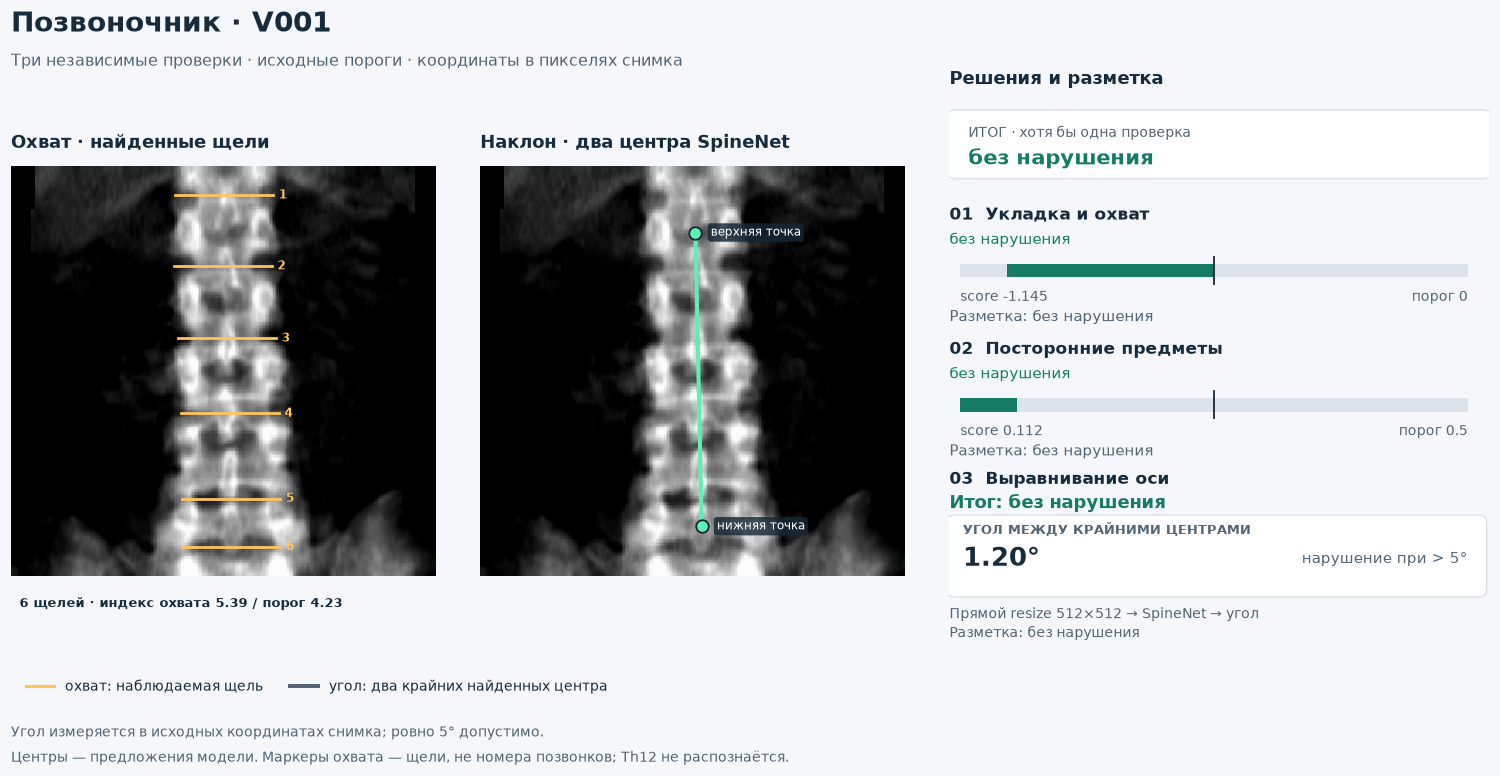

In [23]:
VIEW_ID = 'V001'
by_view = {p['legacy_view_id']: p for p in predictions}
by_id = {r['image_id']: r for r in labels}
selected = by_view[VIEW_ID]
record = by_id[selected['image_id']]
fig = plot_case(ROOT / 'data' / record['native_path'], selected['result'],
                truth=record, title=VIEW_ID)
fig.savefig(OUTPUT / 'selected_case.png', dpi=150, bbox_inches='tight')
plt.show()

## Таблица по каждому из 100 снимков

true — экспертная метка, pred — ответ алгоритма, score — показатель проверки.
У V253 поля true пусты, но предсказания всех трёх проверок и итогового OR есть.

In [24]:
metrics, table = evaluate_predictions(predictions, labels, include_unseen=True,
                                      classifier_bundle=pipeline.bundle)
assert metrics['n_images'] == len(table) == 100
assert table['quality_pred'].notna().all()
assert table['quality_true'].notna().sum() == metrics['n_eligible']
table['has_label'] = table['quality_true'].notna()
columns = ['view_id', 'image_id', 'fold', 'has_label',
           'coverage_true', 'coverage_pred', 'coverage_score',
           'axis_true', 'axis_pred', 'axis_score',
           'artifacts_true', 'artifacts_pred', 'artifacts_score',
           'quality_true', 'quality_pred']
per_image = table[columns].sort_values('view_id').reset_index(drop=True)
per_image.to_csv(OUTPUT / 'per_image_all100.csv', index=False)
per_image.to_csv(OUTPUT / 'per_image.csv', index=False)
with pd.option_context('display.max_rows', 110, 'display.max_columns', 20):
    display(per_image.round(3))
print(f'Предсказания: {len(per_image)}/100; метки: {metrics["n_eligible"]}/100.')

,view_id,image_id,fold,has_label,coverage_true,coverage_pred,coverage_score,axis_true,axis_pred,axis_score,artifacts_true,artifacts_pred,artifacts_score,quality_true,quality_pred
0,V001,img_557a93922c89989db0c4,1,True,0,False,-1.145,0,False,1.203,0,False,0.112,0,False
1,V005,img_2d24a2cb915cebbd5355,1,True,0,False,-0.842,0,False,2.727,0,False,0.473,0,False
2,V009,img_1b09a35414c475457a80,0,True,0,False,-0.737,0,False,0.745,0,False,0.145,0,False
3,V011,img_8f8416380da3e1161fba,4,True,0,False,-1.328,0,False,3.029,0,False,0.162,0,False
4,V014,img_a3b96ac390f596230c66,1,True,0,False,-1.692,1,True,11.459,0,False,0.070,1,True
5,V017,img_10695d06a6ea9ab8e64d,2,True,0,False,-0.392,0,False,4.416,0,False,0.276,0,False
6,V021,img_0fbd2563efd9c0fd8f1a,3,True,0,False,-1.446,0,False,3.221,0,True,0.518,0,True
7,V022,img_8147e442451621deb072,0,True,0,False,-0.824,0,False,4.126,0,False,0.146,0,False
8,V025,img_a4f0a392a62d6a104284,1,True,0,False,-0.453,0,False,2.617,0,False,0.069,0,False
9,V027,img_0c451148f98d8362ac39,4,True,0,False,-0.393,0,False,1.126,1,False,0.376,1,False


Предсказания: 100/100; метки: 99/100.


## Метрики трёх подзадач и итогового OR

Положительный класс — нарушение. Метрики учитывают все снимки с известной
экспертной меткой: сейчас это 99 из 100. Для отдельных проверок ROC AUC
рассчитан по их непрерывным scores. У логического OR непрерывного score нет;
его ROC AUC рассчитан по бинарному решению и равен balanced accuracy.

In [25]:
metric_rows = []
for key in ('coverage', 'axis', 'artifacts', 'quality'):
    item = metrics[key]
    balanced = (item['sensitivity'] + item['specificity']) / 2
    auc = item['roc_auc']
    if key == 'quality':
        known = table[table['quality_true'].notna()]
        auc = roc_auc_score(known['quality_true'].astype(int),
                            known['quality_pred'].astype(int))
    metric_rows.append({
        'Проверка': {'coverage': 'Охват', 'axis': 'Угол',
                     'artifacts': 'Артефакты', 'quality': 'Итог: OR'}[key],
        'С меткой': item['n'], 'F1 score': item['f1'], 'ROC AUC': auc,
        'Balanced accuracy': balanced, 'Accuracy': item['accuracy'],
        'Recall': item['sensitivity'], 'Specificity': item['specificity'],
        'TP': item['tp'], 'FN': item['fn'], 'FP': item['fp'], 'TN': item['tn'],
    })
summary = pd.DataFrame(metric_rows)
display(summary.round(3))
summary.to_csv(OUTPUT / 'metrics_table_all100.csv', index=False)
metrics['n_predicted'] = len(predictions)
metrics['n_unlabeled'] = len(predictions) - metrics['n_eligible']
metrics['n_labeled'] = metrics.pop('n_eligible')
metrics.pop('n_excluded')
metrics['quality']['roc_auc_binary_or'] = float(metric_rows[-1]['ROC AUC'])
metrics['evaluation_role'] = ('100/100 inference; metrics on available labels. '
    'Newly trained study-fold classifiers for the original 96 and full-fit predictions '
    'for additional images absent from training. Not independent test or new CV.')
(OUTPUT / 'metrics.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2))
(OUTPUT / 'metrics_99.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2))
run = {'finished_utc': datetime.now(timezone.utc).isoformat(),
       'device': pipeline.device, 'fresh_inference': True,
       'artifact_classifier_training_performed': True,
       'neural_backbones_pretrained': True,
       'downloaded_on_this_run': download_events,
       'notebook_contains_all_inference_code': True,
       'local_python_modules_imported': False,
       'n_images': len(predictions), 'n_labeled': metrics['n_labeled'],
       'inference_seconds': inference_seconds,
       'axis_method': 'spinenet_direct_512_extreme_centers'}
(OUTPUT / 'run_manifest.json').write_text(json.dumps(run, ensure_ascii=False, indent=2))
print('Итоговое OR: F1 =', round(metrics['quality']['f1'], 3))

,Проверка,С меткой,F1 score,ROC AUC,Balanced accuracy,Accuracy,Recall,Specificity,TP,FN,FP,TN
0,Охват,99,0.769,0.971,0.906,0.970,0.833,0.978,5,1,2,91
1,Угол,99,0.615,0.884,0.855,0.899,0.800,0.910,8,2,8,81
2,Артефакты,99,0.605,0.857,0.803,0.828,0.765,0.841,13,4,13,69
3,Итог: OR,99,0.740,0.825,0.825,0.808,0.871,0.779,27,4,15,53


Итоговое OR: F1 = 0.74
